In [1]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, mannwhitneyu, chi2_contingency
from scipy import stats
from wordcloud import WordCloud
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()
import emoji
import string
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [2]:
#Input files path
folder_path = "/Users/sunnybhardwaj/Desktop/Project_dataset/Final/"

trend = pd.read_csv(folder_path + "IN_youtube_trending_data.csv", dtype={'video_id': str}) #rows - 251277, col - 16
non_trend = pd.read_csv(folder_path + "temp_non_trending_videos.csv", dtype={'video_id': str}) #rows - 13868, col - 17
trend_video_length = pd.read_csv(folder_path + "IN_youtube_trending_req_col_with_lengths.csv", dtype={'video_id': str}) #rows - 12491, col - 2

In [3]:
#JSON file path
json_path = '/Users/sunnybhardwaj/Desktop/Project_dataset/Final/IN_category_id.json'

#Read the JSON file
with open(json_path, 'r', encoding='utf-8') as file:
    json_data = pd.read_json(file)

#Check the type of the data in the JSON file
type(json_data)

pandas.core.frame.DataFrame

In [4]:
#Check the columns in the JSON file
json_data.columns

Index(['kind', 'etag', 'items'], dtype='object')

In [5]:
#As data is nested so normalizing it
category = pd.json_normalize(json_data['items']) #rows - 31, col - 6
category.columns

Index(['kind', 'etag', 'id', 'snippet.title', 'snippet.assignable',
       'snippet.channelId'],
      dtype='object')

In [6]:
#Renaming the column names and filtering the required columns in the dataframe
category_df = category[['id', 'snippet.title']].rename(columns={
    'id': 'categoryId',
    'snippet.title': 'category'
})

In [7]:
#Check the columns in all four dataframes

In [8]:
trend.columns

Index(['video_id', 'title', 'publishedAt', 'channelId', 'channelTitle',
       'categoryId', 'trending_date', 'tags', 'view_count', 'likes',
       'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled',
       'ratings_disabled', 'description'],
      dtype='object')

In [9]:
non_trend.columns

Index(['video_id', 'title', 'publishedAt', 'channelId', 'channelTitle',
       'categoryId', 'trending_status', 'tags', 'view_count', 'likes',
       'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled',
       'ratings_disabled', 'description', 'video_duration_seconds'],
      dtype='object')

In [10]:
category_df.columns

Index(['categoryId', 'category'], dtype='object')

In [11]:
trend_video_length.columns

Index(['video_id', 'video_duration_seconds'], dtype='object')

In [12]:
#Correct the datatype of the columns and filter only 2023 trending videos
trend['trending_date'] = pd.to_datetime(trend['trending_date'])
trend['publishedAt'] = pd.to_datetime(trend['publishedAt'])

trend_2023 = trend[trend['trending_date'].dt.year == 2023]
trend_2023 = trend_2023.copy()
trend_2023.shape

(65382, 16)

In [13]:
#Correct the datatype of the columns and filter only 2023 published videos (non trending)
non_trend['publishedAt'] = pd.to_datetime(non_trend['publishedAt'])

non_trend_2023 = non_trend[non_trend['publishedAt'].dt.year == 2023]
non_trend_2023 = non_trend_2023.copy()
non_trend_2023.shape

(13862, 17)

In [14]:
#Add video duration column to trending videos dataset
trend_2023 = trend_2023.merge(trend_video_length, on='video_id', how='left')
trend_2023.shape

(65382, 17)

In [15]:
#Concatenating trending and non trending dataframes
#In trending dataset there is "trending_date" extra while in non trending dataset there is "trending_status" which is extra
#Adding these missing columns in the dataframes
trend_2023["trending_status"] = 'Trending'
non_trend_2023["trending_date"] = pd.NaT #pd.NaT is the datetime equivalent of NaN (Not a Number)
all_videos = pd.concat([trend_2023, non_trend_2023], ignore_index = True)

all_videos.shape

(79244, 18)

In [16]:
#Before merging the dataframes on categoryId, make sure the datatype is same in all dataframes

In [17]:
all_videos["categoryId"].dtype #int64

dtype('int64')

In [18]:
category_df["categoryId"].dtype #Object

dtype('O')

In [19]:
#Change the datatype of categoryId to int64 in category_df
category_df["categoryId"] = category_df["categoryId"].astype('int64')

category_df["categoryId"].dtype

dtype('int64')

In [21]:
#Check the shape of the dataframe before merging to make sure merge is happening correctly
all_videos.shape

(79244, 18)

In [22]:
#Merging the category dataframe with all video dataframe
all_videos_w_cat = all_videos.merge(category_df, on="categoryId", how='left')

all_videos_w_cat.shape

(79244, 19)

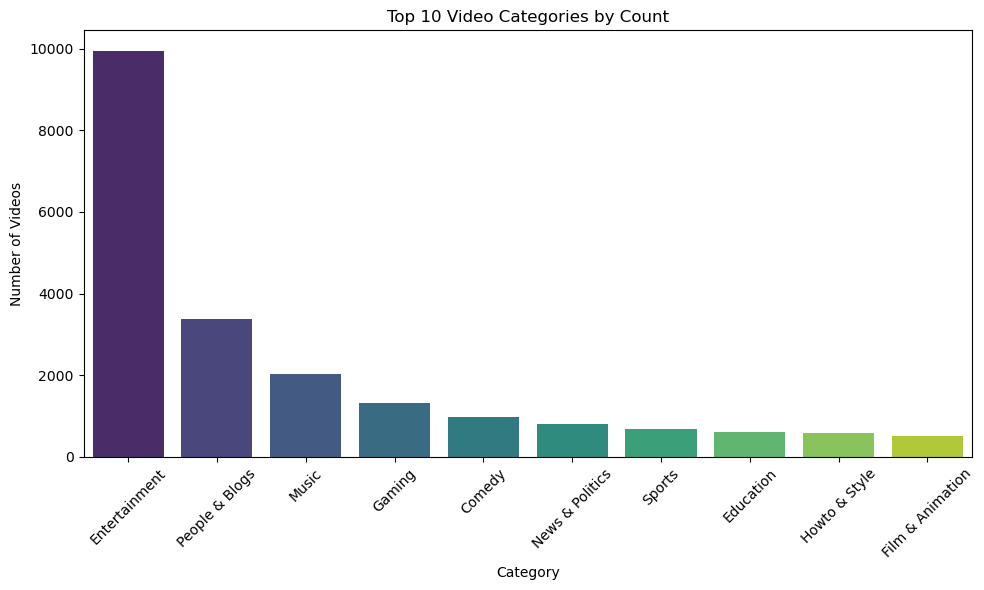

In [23]:
##Checking the top categories
trend_w_cat = all_videos_w_cat[all_videos_w_cat['trending_status']=='Trending']
trend_w_cat.columns
trend_w_cat = trend_w_cat[['video_id', 'category']].drop_duplicates()
plt.figure(figsize=(10, 6))
top_10_categories = trend_w_cat['category'].value_counts().head(10)
sns.barplot(x=top_10_categories.index, y=top_10_categories.values, hue=top_10_categories.index, palette='viridis', legend=False )

plt.xticks(rotation=45)
plt.title("Top 10 Video Categories by Count")
plt.xlabel("Category")
plt.ylabel("Number of Videos")
plt.tight_layout()
plt.show()

In [24]:
#Filter the dataframe with required rows
#Doing analysis on Top 3 categories for videos trended in 2023 and didn't trend but published in 2023

In [25]:
#Filter the top 3 categories (10-Music, 20-Gaming, 24-Entertainment)
all_videos_2023_filt = all_videos_w_cat[all_videos_w_cat["categoryId"].isin([10, 20, 24])]
all_videos_2023_filt.shape

(51832, 19)

In [26]:
#Unique videoID number for trending, non trending  and all videos
all_videos_2023_filt["trending_status"].unique()

array(['Trending', 'Non-Trending'], dtype=object)

In [27]:
#All
all_videos_2023_filt["video_id"].nunique()

26209

In [28]:
#Trending
all_videos_2023_filt[all_videos_2023_filt["trending_status"] == 'Trending']["video_id"].nunique()

13292

In [29]:
#Non Trending
all_videos_2023_filt[all_videos_2023_filt["trending_status"] == 'Non-Trending']["video_id"].nunique()

12917

In [30]:
#Unique channelID number
all_videos_2023_filt["channelId"].nunique()

1250

In [31]:
#Check for null values in the columns
all_videos_2023_filt.isnull().sum()

video_id                      0
title                         0
publishedAt                   0
channelId                     0
channelTitle                  0
categoryId                    0
trending_date             12917
tags                          0
view_count                    0
likes                         0
dislikes                  12917
comment_count                 0
thumbnail_link                0
comments_disabled             0
ratings_disabled              0
description                2817
video_duration_seconds     2031
trending_status               0
category                      0
dtype: int64

In [32]:
#trending_date              12917 #it is fine as non trending videos do not have trending date
#dislikes                   12917 #it is fine as youtube has stopped giving details on dislikes
#description                2817 #it is possible, videos without description
#video_duration_seconds    2031 #these video ids can be deleted if video duration turns out to be impactful for trendiness

In [33]:
#check column info
all_videos_2023_filt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51832 entries, 1 to 79243
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   video_id                51832 non-null  object             
 1   title                   51832 non-null  object             
 2   publishedAt             51832 non-null  datetime64[ns, UTC]
 3   channelId               51832 non-null  object             
 4   channelTitle            51832 non-null  object             
 5   categoryId              51832 non-null  int64              
 6   trending_date           38915 non-null  object             
 7   tags                    51832 non-null  object             
 8   view_count              51832 non-null  int64              
 9   likes                   51832 non-null  int64              
 10  dislikes                38915 non-null  float64            
 11  comment_count           51832 non-null  int64 

In [34]:
#Changing datatypes where required
all_videos_2023_filt['trending_date'] = pd.to_datetime(all_videos_2023_filt['trending_date'])

all_videos_2023_filt['category'] = all_videos_2023_filt['category'].astype('category')
all_videos_2023_filt['trending_status'] = all_videos_2023_filt['trending_status'].astype('category')

/var/folders/wy/chnwk9lj6s35f_7rpwxky1y00000gn/T/ipykernel_25569/3236256982.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_videos_2023_filt['trending_date'] = pd.to_datetime(all_videos_2023_filt['trending_date'])
/var/folders/wy/chnwk9lj6s35f_7rpwxky1y00000gn/T/ipykernel_25569/3236256982.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_videos_2023_filt['category'] = all_videos_2023_filt['category'].astype('category')
/var/folders/wy/chnwk9lj6s35f_7rpwxky1y00000gn/T/ipykernel_25569/3236256982

In [35]:
#There are some videos which trended for more than 1 day, keep the first day it trended
all_videos_2023_filt = all_videos_2023_filt.sort_values(by=['video_id', 'trending_date'])
all_videos_2023_final = all_videos_2023_filt.groupby('video_id').head(1)
all_videos_2023_final.shape

(26209, 19)

In [36]:
all_videos_2023_final.columns

Index(['video_id', 'title', 'publishedAt', 'channelId', 'channelTitle',
       'categoryId', 'trending_date', 'tags', 'view_count', 'likes',
       'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled',
       'ratings_disabled', 'description', 'video_duration_seconds',
       'trending_status', 'category'],
      dtype='object')

Creating new features from the existing ones

In [38]:
#Rolling Count of Prior Trending Videos (per channel)

In [39]:
#Count the rolling version of "number of trending videos per channel", to ensure to only count how many earlier videos from the same channel have trended before the particular video uploaded
#Filter for 2023 uploads only #As there are just around 94 videos with publish date 2022 so can ignore those for this 
df_2023 = all_videos_2023_final.copy()
df_2023['publishedAt'] = pd.to_datetime(df_2023['publishedAt'])
df_2023 = df_2023[df_2023['publishedAt'].dt.year == 2023]

#Sort within each channel by publish time
df_2023 = df_2023.sort_values(['channelId', 'publishedAt'])

#Create a binary column for trending videos
df_2023['is_trending'] = (df_2023['trending_status'] == 'Trending').astype(int)

#Rolling sum (cumulative count of trending videos before current one)
df_2023['prior_trending_count'] = (
    df_2023
    .groupby('channelId')['is_trending']
    .cumsum()
    .shift(fill_value=0)
)

#Now map this back to the original dataframe
#Create a mapping from video_id & prior_trending_count
prior_trending_map = df_2023.set_index('video_id')['prior_trending_count']

#Assign to original full dataframe
all_videos_2023_final['prior_trending_count'] = all_videos_2023_final['video_id'].map(prior_trending_map).fillna(0).astype(int)
all_videos_2023_final.head(5)

/var/folders/wy/chnwk9lj6s35f_7rpwxky1y00000gn/T/ipykernel_25569/3150005325.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_videos_2023_final['prior_trending_count'] = all_videos_2023_final['video_id'].map(prior_trending_map).fillna(0).astype(int)


,video_id,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,description,video_duration_seconds,trending_status,category,prior_trending_count
72780,--0zecPP2Kc,Bolti Bandh | Episode 6 | Watch Now!,2023-12-26 02:30:00+00:00,UCe31NPEeRGO0hcznx6Tdb-g,BATTLEGROUNDS MOBILE INDIA,20,NaT,"['BATTLEGROUNDS MOBILE INDIA', 'BATTLEGROUNDSM...",2017674,84181,NaN,50,https://i.ytimg.com/vi/--0zecPP2Kc/default.jpg,False,False,How far can a BGMI player go using the shared ...,275.0,Non-Trending,Gaming,16
76423,--MFuyOvrdU,Anbe En Kanavu Kaadhalaney - Navayuga Kannagi ...,2023-12-12 11:25:00+00:00,UCUgP5pdToi19fWe19NVliFg,TrendMusic,10,NaT,"['anbe en kanavu kaadhalaney', 'navayuga kanna...",13595,528,NaN,59,https://i.ytimg.com/vi/--MFuyOvrdU/default.jpg,False,True,Presenting you #AnbeEnKanavuKaadhalaney Song f...,264.0,Non-Trending,Music,4
50957,--Xznxew7y4,Chore Haryane Aale - Elvish Yadav | Ankit Baiy...,2023-10-08 05:30:00+00:00,UCXRBqdfByGIZeFWBIuWFUUA,Play DMF Haryanvi,10,2023-10-09 00:00:00+00:00,Chore Haryane Aale|Elvishi Yadav|Elvish yadav ...,4123149,641629,0.0,72194,https://i.ytimg.com/vi/--Xznxew7y4/default.jpg,False,False,Anshul Garg presents of Chore Haryane Aale fea...,203.0,Trending,Music,1
78677,--YRoepb98U,మాకిదే Good News || Super Sujatha || Rocking R...,2023-10-20 11:30:00+00:00,UCTVl--goYz1HaeuaTqK3F4g,Super Sujatha,24,NaT,"['Super Sujatha', 'Super Sujatha Channel', 'Su...",249283,2333,NaN,78,https://i.ytimg.com/vi/--YRoepb98U/default.jpg,False,False,#partnership\nCheck out Mamaearth's amazing Ri...,1394.0,Non-Trending,Entertainment,7
74466,--ZhPAv_ijE,😍our shop open🤩 | ￼ ask me question ? aJ squad ￼,2023-12-21 09:55:49+00:00,UC0seixKXNAJj0fyMoUpK6pA,Content illa Mamey,24,NaT,"['Vlog', 'Travel', 'TTF', 'Ajsquad', 'Twin thr...",67656,4826,NaN,98,https://i.ytimg.com/vi/--ZhPAv_ijE/default.jpg,False,False,#ajsquad #ruling\n\nFor advertisement and busi...,2082.0,Non-Trending,Entertainment,1


In [40]:
#Extract publish day and hour from published date
all_videos_2023_final['publish_day'] = all_videos_2023_final['publishedAt'].dt.day_name()
all_videos_2023_final['publish_hour'] = all_videos_2023_final['publishedAt'].dt.hour
all_videos_2023_final.head(5)

/var/folders/wy/chnwk9lj6s35f_7rpwxky1y00000gn/T/ipykernel_25569/2977969786.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_videos_2023_final['publish_day'] = all_videos_2023_final['publishedAt'].dt.day_name()
/var/folders/wy/chnwk9lj6s35f_7rpwxky1y00000gn/T/ipykernel_25569/2977969786.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_videos_2023_final['publish_hour'] = all_videos_2023_final['publishedAt'].dt.hour


,video_id,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,...,thumbnail_link,comments_disabled,ratings_disabled,description,video_duration_seconds,trending_status,category,prior_trending_count,publish_day,publish_hour
72780,--0zecPP2Kc,Bolti Bandh | Episode 6 | Watch Now!,2023-12-26 02:30:00+00:00,UCe31NPEeRGO0hcznx6Tdb-g,BATTLEGROUNDS MOBILE INDIA,20,NaT,"['BATTLEGROUNDS MOBILE INDIA', 'BATTLEGROUNDSM...",2017674,84181,...,https://i.ytimg.com/vi/--0zecPP2Kc/default.jpg,False,False,How far can a BGMI player go using the shared ...,275.0,Non-Trending,Gaming,16,Tuesday,2
76423,--MFuyOvrdU,Anbe En Kanavu Kaadhalaney - Navayuga Kannagi ...,2023-12-12 11:25:00+00:00,UCUgP5pdToi19fWe19NVliFg,TrendMusic,10,NaT,"['anbe en kanavu kaadhalaney', 'navayuga kanna...",13595,528,...,https://i.ytimg.com/vi/--MFuyOvrdU/default.jpg,False,True,Presenting you #AnbeEnKanavuKaadhalaney Song f...,264.0,Non-Trending,Music,4,Tuesday,11
50957,--Xznxew7y4,Chore Haryane Aale - Elvish Yadav | Ankit Baiy...,2023-10-08 05:30:00+00:00,UCXRBqdfByGIZeFWBIuWFUUA,Play DMF Haryanvi,10,2023-10-09 00:00:00+00:00,Chore Haryane Aale|Elvishi Yadav|Elvish yadav ...,4123149,641629,...,https://i.ytimg.com/vi/--Xznxew7y4/default.jpg,False,False,Anshul Garg presents of Chore Haryane Aale fea...,203.0,Trending,Music,1,Sunday,5
78677,--YRoepb98U,మాకిదే Good News || Super Sujatha || Rocking R...,2023-10-20 11:30:00+00:00,UCTVl--goYz1HaeuaTqK3F4g,Super Sujatha,24,NaT,"['Super Sujatha', 'Super Sujatha Channel', 'Su...",249283,2333,...,https://i.ytimg.com/vi/--YRoepb98U/default.jpg,False,False,#partnership\nCheck out Mamaearth's amazing Ri...,1394.0,Non-Trending,Entertainment,7,Friday,11
74466,--ZhPAv_ijE,😍our shop open🤩 | ￼ ask me question ? aJ squad ￼,2023-12-21 09:55:49+00:00,UC0seixKXNAJj0fyMoUpK6pA,Content illa Mamey,24,NaT,"['Vlog', 'Travel', 'TTF', 'Ajsquad', 'Twin thr...",67656,4826,...,https://i.ytimg.com/vi/--ZhPAv_ijE/default.jpg,False,False,#ajsquad #ruling\n\nFor advertisement and busi...,2082.0,Non-Trending,Entertainment,1,Thursday,9


In [41]:
##Title

In [42]:
#Add a new column for title length
all_videos_2023_final['title_length'] = all_videos_2023_final['title'].apply(len)

/var/folders/wy/chnwk9lj6s35f_7rpwxky1y00000gn/T/ipykernel_25569/2331792758.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_videos_2023_final['title_length'] = all_videos_2023_final['title'].apply(len)


In [43]:
#Title Text sentiment
def get_sentiment_scores(title):
    scores = analyzer.polarity_scores(str(title))
    return pd.Series([scores['compound']])

#Apply to the DataFrame and find text sentiment of the titles
all_videos_2023_final[['title_sentiment_compound']] = all_videos_2023_final['title'].apply(get_sentiment_scores)

/var/folders/wy/chnwk9lj6s35f_7rpwxky1y00000gn/T/ipykernel_25569/740516602.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_videos_2023_final[['title_sentiment_compound']] = all_videos_2023_final['title'].apply(get_sentiment_scores)


In [44]:
#Impact of emojis in title
#Create column "title_has_emoji", to check the impact of emoji in title
emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map symbols
    "\U0001F1E0-\U0001F1FF"  # flags (iOS)
    "\U00002700-\U000027BF"  # dingbats
    "\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE,
)
all_videos_2023_final['title_has_emoji'] = all_videos_2023_final['title'].apply(lambda x: int(bool(emoji_pattern.search(str(x)))))

/var/folders/wy/chnwk9lj6s35f_7rpwxky1y00000gn/T/ipykernel_25569/3735419345.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_videos_2023_final['title_has_emoji'] = all_videos_2023_final['title'].apply(lambda x: int(bool(emoji_pattern.search(str(x)))))


In [45]:
all_videos_2023_final.head(5)

,video_id,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,...,description,video_duration_seconds,trending_status,category,prior_trending_count,publish_day,publish_hour,title_length,title_sentiment_compound,title_has_emoji
72780,--0zecPP2Kc,Bolti Bandh | Episode 6 | Watch Now!,2023-12-26 02:30:00+00:00,UCe31NPEeRGO0hcznx6Tdb-g,BATTLEGROUNDS MOBILE INDIA,20,NaT,"['BATTLEGROUNDS MOBILE INDIA', 'BATTLEGROUNDSM...",2017674,84181,...,How far can a BGMI player go using the shared ...,275.0,Non-Trending,Gaming,16,Tuesday,2,36,0.0000,0
76423,--MFuyOvrdU,Anbe En Kanavu Kaadhalaney - Navayuga Kannagi ...,2023-12-12 11:25:00+00:00,UCUgP5pdToi19fWe19NVliFg,TrendMusic,10,NaT,"['anbe en kanavu kaadhalaney', 'navayuga kanna...",13595,528,...,Presenting you #AnbeEnKanavuKaadhalaney Song f...,264.0,Non-Trending,Music,4,Tuesday,11,99,0.0000,0
50957,--Xznxew7y4,Chore Haryane Aale - Elvish Yadav | Ankit Baiy...,2023-10-08 05:30:00+00:00,UCXRBqdfByGIZeFWBIuWFUUA,Play DMF Haryanvi,10,2023-10-09 00:00:00+00:00,Chore Haryane Aale|Elvishi Yadav|Elvish yadav ...,4123149,641629,...,Anshul Garg presents of Chore Haryane Aale fea...,203.0,Trending,Music,1,Sunday,5,94,0.2500,0
78677,--YRoepb98U,మాకిదే Good News || Super Sujatha || Rocking R...,2023-10-20 11:30:00+00:00,UCTVl--goYz1HaeuaTqK3F4g,Super Sujatha,24,NaT,"['Super Sujatha', 'Super Sujatha Channel', 'Su...",249283,2333,...,#partnership\nCheck out Mamaearth's amazing Ri...,1394.0,Non-Trending,Entertainment,7,Friday,11,80,0.7351,0
74466,--ZhPAv_ijE,😍our shop open🤩 | ￼ ask me question ? aJ squad ￼,2023-12-21 09:55:49+00:00,UC0seixKXNAJj0fyMoUpK6pA,Content illa Mamey,24,NaT,"['Vlog', 'Travel', 'TTF', 'Ajsquad', 'Twin thr...",67656,4826,...,#ajsquad #ruling\n\nFor advertisement and busi...,2082.0,Non-Trending,Entertainment,1,Thursday,9,49,0.4588,1


In [46]:
#Common words in trending video titles

In [47]:
#Function to clean the title and tokenize
def clean_and_tokenize(text):
    text = str(text).lower()
    
    # Replace all common separators (ASCII and Unicode variants) with space
    separators = ['|', '│', '┃', '-', '/', '\\', '_', ':']
    for sep in separators:
        text = text.replace(sep, ' ')
    
    #Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation)) 
    
    #Remove emojis
    text = ''.join([ch for ch in text if ch not in emoji.EMOJI_DATA])
    
    #Tokenize words
    words = text.split()
    
    #Remove stopwords
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    
    #Return combined tokens
    return words

In [48]:
#Clean the title and tokenize
all_videos_2023_final['title_tokens'] = all_videos_2023_final['title'].apply(clean_and_tokenize)

#Separate trending and non-trending
trending_tokens = all_videos_2023_final[all_videos_2023_final['trending_status'] == 'Trending']['title_tokens']
non_trending_tokens = all_videos_2023_final[all_videos_2023_final['trending_status'] == 'Non-Trending']['title_tokens']

#Flatten token lists
flat_trending = [token for tokens in trending_tokens for token in tokens]
flat_non_trending = [token for tokens in non_trending_tokens for token in tokens]

#Count frequencies
trending_freq = Counter(flat_trending)
non_trending_freq = Counter(flat_non_trending)

#Calculate importance (ratio)
word_importance = {}
for word in trending_freq:
    trend_count = trending_freq[word]
    non_trend_count = non_trending_freq.get(word, 1)  #Avoid division by zero
    ratio = trend_count / non_trend_count
    word_importance[word] = ratio

#Display top important words
#Trending
#Sort by importance
sorted_words = sorted(word_importance.items(), key=lambda x: x[1], reverse=True)
top_words_trend = pd.DataFrame(sorted_words[:20], columns=['word', 'trending_ratio'])
top_words_trend.head(5)

/var/folders/wy/chnwk9lj6s35f_7rpwxky1y00000gn/T/ipykernel_25569/1983654437.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_videos_2023_final['title_tokens'] = all_videos_2023_final['title'].apply(clean_and_tokenize)


,word,trending_ratio
0,ethirneechal,389.0
1,presented,281.0
2,ary,274.0
3,digitally,232.0
4,radhakrishn,224.0


In [49]:
##Tags

In [50]:
#Function to clean tags
def process_tags(tag_input):
    if pd.isnull(tag_input):
        return []
    
    #If it's already a list, clean and normalize it
    if isinstance(tag_input, list):
        tokens = [tag.strip().lower() for tag in tag_input if tag.strip()]
        return tokens
    
    #If it's a string, check for separators
    if isinstance(tag_input, str):
        if '|' in tag_input:
            parts = tag_input.split('|')
        elif ',' in tag_input:
            parts = tag_input.split(',')
        else:
            parts = [tag_input]
        tokens = [part.strip().lower() for part in parts if part.strip() and part.strip().lower() != '[none]']
        return tokens
    
    #If none of the above, return empty list
    return []

In [51]:
#Clean and tokenize tags
all_videos_2023_final['tag_tokens'] = all_videos_2023_final['tags'].apply(process_tags)

# Separate trending and non-trending tags
trending_tags = all_videos_2023_final[all_videos_2023_final['trending_status'] == 'Trending']['tag_tokens']
non_trending_tags = all_videos_2023_final[all_videos_2023_final['trending_status'] == 'Non-Trending']['tag_tokens']

# Flatten lists to single list of tags
flat_trending_tags = [tag for sublist in trending_tags for tag in sublist]
flat_non_trending_tags = [tag for sublist in non_trending_tags for tag in sublist]

# Count frequency
trending_tag_counts = Counter(flat_trending_tags)
non_trending_tag_counts = Counter(flat_non_trending_tags)

# Calculate importance ratio (avoid division by zero)
tag_importance = {}
for tag in trending_tag_counts:
    trend_count = trending_tag_counts[tag]
    non_trend_count = non_trending_tag_counts.get(tag, 1)
    ratio = trend_count / non_trend_count
    tag_importance[tag] = ratio

# Sort tags by importance descending
sorted_tags = sorted(tag_importance.items(), key=lambda x: x[1], reverse=True)

#Top 20 tags in trending videos
top_trending_tags = pd.DataFrame(sorted_tags[:20], columns=['Tag', 'Trending_Ratio'])
top_trending_tags.head(5)

/var/folders/wy/chnwk9lj6s35f_7rpwxky1y00000gn/T/ipykernel_25569/932252243.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_videos_2023_final['tag_tokens'] = all_videos_2023_final['tags'].apply(process_tags)


,Tag,Trending_Ratio
0,comedy,1033.0
1,family,843.0
2,drama,810.0
3,entertainment,785.0
4,funny,718.0


In [52]:
#Number of tags
all_videos_2023_final['tags_count'] = all_videos_2023_final['tag_tokens'].apply(len)

/var/folders/wy/chnwk9lj6s35f_7rpwxky1y00000gn/T/ipykernel_25569/2386127509.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_videos_2023_final['tags_count'] = all_videos_2023_final['tag_tokens'].apply(len)


In [53]:
##Title–Tag Relevance Ratio
#If the title aligns well with tags, the video is more likely to rank in relevant searches.
all_videos_2023_final['title_tokens'] = all_videos_2023_final['title_tokens'].apply(lambda x: set(x) if isinstance(x, list) else set())
all_videos_2023_final['tag_tokens'] = all_videos_2023_final['tag_tokens'].apply(lambda x: set(x) if isinstance(x, list) else set())

# Title–Tag Relevance Ratio
all_videos_2023_final['title_tag_ratio'] = all_videos_2023_final.apply(
    lambda row: len(row['title_tokens'] & row['tag_tokens']) / len(row['title_tokens'])
                if len(row['title_tokens']) > 0 else 0,
    axis=1
)

/var/folders/wy/chnwk9lj6s35f_7rpwxky1y00000gn/T/ipykernel_25569/3583652265.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_videos_2023_final['title_tokens'] = all_videos_2023_final['title_tokens'].apply(lambda x: set(x) if isinstance(x, list) else set())
/var/folders/wy/chnwk9lj6s35f_7rpwxky1y00000gn/T/ipykernel_25569/3583652265.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_videos_2023_final['tag_tokens'] = all_videos_2023_final['tag_tokens'].apply(lambda x: set(x) if isinstance(x, list) 

In [54]:
##Description
def extract_vader_features(desc):
    desc = str(desc)
    links = len(re.findall(r'http[s]?://\S+', desc))
    hashtags = len(re.findall(r'#\w+', desc))
    sentiment_scores = analyzer.polarity_scores(desc)
    return pd.Series([
        len(desc),
        links,
        hashtags,
        sentiment_scores['compound']
    ])

all_videos_2023_final[['desc_length', 'desc_links_count', 'desc_hashtags_count', 'desc_sentiment']] = all_videos_2023_final['description'].apply(extract_vader_features)

/var/folders/wy/chnwk9lj6s35f_7rpwxky1y00000gn/T/ipykernel_25569/3680034055.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_videos_2023_final[['desc_length', 'desc_links_count', 'desc_hashtags_count', 'desc_sentiment']] = all_videos_2023_final['description'].apply(extract_vader_features)
/var/folders/wy/chnwk9lj6s35f_7rpwxky1y00000gn/T/ipykernel_25569/3680034055.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_videos_2023_final[['desc_length', 'desc_links_count', 'desc_hashtags_count', 'des

In [55]:
#Description Richness Score
#Measures how “promotional” or “dense” the description is relative to its length.
#Could indicate professional upload practices vs casual uploads.
all_videos_2023_final['desc_richness'] = (
    (all_videos_2023_final['desc_links_count'] + all_videos_2023_final['desc_hashtags_count']) /
    all_videos_2023_final['desc_length'].replace(0, 1)  # avoid division by zero
)

/var/folders/wy/chnwk9lj6s35f_7rpwxky1y00000gn/T/ipykernel_25569/493746877.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_videos_2023_final['desc_richness'] = (


In [56]:
all_videos_2023_final.columns

Index(['video_id', 'title', 'publishedAt', 'channelId', 'channelTitle',
       'categoryId', 'trending_date', 'tags', 'view_count', 'likes',
       'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled',
       'ratings_disabled', 'description', 'video_duration_seconds',
       'trending_status', 'category', 'prior_trending_count', 'publish_day',
       'publish_hour', 'title_length', 'title_sentiment_compound',
       'title_has_emoji', 'title_tokens', 'tag_tokens', 'tags_count',
       'title_tag_ratio', 'desc_length', 'desc_links_count',
       'desc_hashtags_count', 'desc_sentiment', 'desc_richness'],
      dtype='object')

In [57]:
all_videos_2023_final.head(5)

,video_id,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,...,title_has_emoji,title_tokens,tag_tokens,tags_count,title_tag_ratio,desc_length,desc_links_count,desc_hashtags_count,desc_sentiment,desc_richness
72780,--0zecPP2Kc,Bolti Bandh | Episode 6 | Watch Now!,2023-12-26 02:30:00+00:00,UCe31NPEeRGO0hcznx6Tdb-g,BATTLEGROUNDS MOBILE INDIA,20,NaT,"['BATTLEGROUNDS MOBILE INDIA', 'BATTLEGROUNDSM...",2017674,84181,...,0,"{6, watch, bolti, episode, bandh}","{['battlegrounds mobile india', 'battlegrounds...",9,0.0,201.0,0.0,2.0,-0.1027,0.009950
76423,--MFuyOvrdU,Anbe En Kanavu Kaadhalaney - Navayuga Kannagi ...,2023-12-12 11:25:00+00:00,UCUgP5pdToi19fWe19NVliFg,TrendMusic,10,NaT,"['anbe en kanavu kaadhalaney', 'navayuga kanna...",13595,528,...,0,"{anbe, kannagi, shortflix, kanavu, navayuga, d...","{'tamil romantic songs', 'alvinbruno'], 'chinm...",23,0.0,2522.0,13.0,5.0,0.1531,0.007137
50957,--Xznxew7y4,Chore Haryane Aale - Elvish Yadav | Ankit Baiy...,2023-10-08 05:30:00+00:00,UCXRBqdfByGIZeFWBIuWFUUA,Play DMF Haryanvi,10,2023-10-09 00:00:00+00:00,Chore Haryane Aale|Elvishi Yadav|Elvish yadav ...,4123149,641629,...,0,"{dg, garg, haryane, af, anshul, chore, yadav, ...","{elvish yadav song, #shorts, desi music factor...",18,0.0,2917.0,1.0,0.0,0.8689,0.000343
78677,--YRoepb98U,మాకిదే Good News || Super Sujatha || Rocking R...,2023-10-20 11:30:00+00:00,UCTVl--goYz1HaeuaTqK3F4g,Super Sujatha,24,NaT,"['Super Sujatha', 'Super Sujatha Channel', 'Su...",249283,2333,...,0,"{sujatha, good, rakesh, vlogs, strikers, news,...","{'chantabbai', 'rocking rakesh', 'super sujath...",15,0.0,683.0,6.0,4.0,0.8779,0.014641
74466,--ZhPAv_ijE,😍our shop open🤩 | ￼ ask me question ? aJ squad ￼,2023-12-21 09:55:49+00:00,UC0seixKXNAJj0fyMoUpK6pA,Content illa Mamey,24,NaT,"['Vlog', 'Travel', 'TTF', 'Ajsquad', 'Twin thr...",67656,4826,...,1,"{￼, squad, shop, aj, question, open, ask}","{'tamil love', 'bike accident tamil', 'walk an...",33,0.0,174.0,1.0,2.0,0.0000,0.017241


In [58]:
#deleting the columns which are not required for the analysis
all_videos_2023_final = all_videos_2023_final.drop(columns=['publishedAt', 'channelId', 'channelTitle', 
                                                            'categoryId', 'trending_date', 'view_count', 'likes',
                                                            'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled',
                                                            'ratings_disabled', 'category'])

Exploratory Data Analysis (EDA)

Univariate Analysis (Analysing only pre-upload feature)

In [61]:
#List of numerical features
features_num = ['video_duration_seconds', 'prior_trending_count', 'title_length', 
             'title_sentiment_compound', 'tags_count', 'title_tag_ratio', 'desc_length', 'desc_links_count', 
             'desc_hashtags_count', 'desc_sentiment', 'desc_richness']

#List of categorical features
features_categ = ['publish_day', 'publish_hour', 'title_has_emoji']

#Convert to category type
for col in features_categ:
    all_videos_2023_final[col] = all_videos_2023_final[col].astype('category')

In [62]:
#Function to compute stats for numeric features
def get_stats(series):
    return pd.Series({
        "Count": series.count(),
        "Mean": series.mean(),
        "Median": series.median(),
        "Std Dev": series.std(),
        "Min": series.min(),
        "Max": series.max(),
        "Skewness": skew(series.dropna())
    })

In [63]:
#Summary of descriptive statistics for all features

In [64]:
#Stats for numerical features
features_num_stats = all_videos_2023_final[features_num].apply(get_stats)

#Round for readability
features_num_stats = features_num_stats.round(2)

print(features_num_stats)

          video_duration_seconds  prior_trending_count  title_length  \
Count                   25408.00              26209.00      26209.00   
Mean                      819.57                 42.69         72.59   
Median                    349.50                  6.00         77.00   
Std Dev                  1763.74                101.02         22.69   
Min                         0.00                  0.00          1.00   
Max                     42900.00                748.00        100.00   
Skewness                    7.96                  3.62         -0.56   

          title_sentiment_compound  tags_count  title_tag_ratio  desc_length  \
Count                     26209.00    26209.00         26209.00     26209.00   
Mean                          0.08       16.55             0.04       996.56   
Median                        0.00       18.00             0.00       781.00   
Std Dev                       0.33       11.34             0.10       930.19   
Min                    

In [65]:
#Stats for categorical features
features_categ_stats = all_videos_2023_final[features_categ].describe().T

print(features_categ_stats)

                 count unique     top   freq
publish_day      26209      7  Sunday   4170
publish_hour     26209     24      12   2229
title_has_emoji  26209      2       0  22188


In [66]:
#Exporting the stats
features_num_stats = features_num_stats.reset_index().rename(columns={"index": "Feature"})
features_categ_stats = features_categ_stats.reset_index().rename(columns={"index": "Feature"})

features_num_stats.to_csv(folder_path + 'desc_stats_num.csv', index=False)
features_categ_stats.to_csv(folder_path + 'desc_stats_categ.csv', index=False)

In [67]:
##Numerical Pre-upload features
numerical_cols_pre = ['video_duration_seconds', 'prior_trending_count']

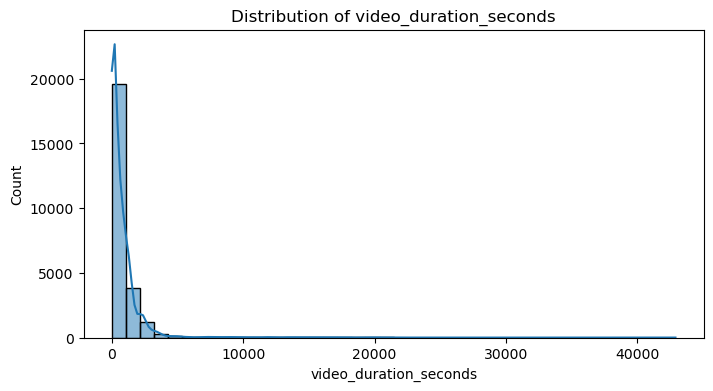

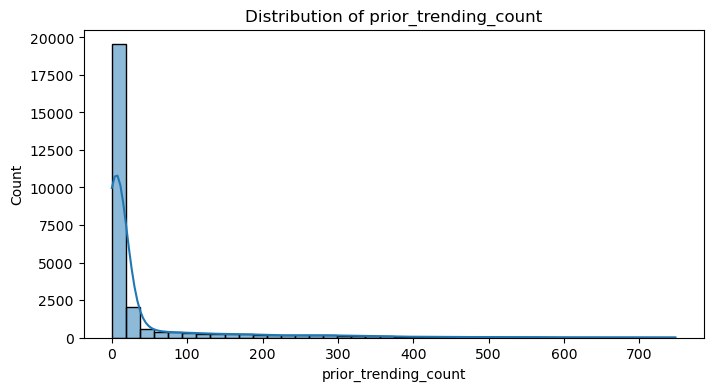

In [68]:
#Plot and check for each feature #raw values
for col in numerical_cols_pre:
    plt.figure(figsize=(8, 4))
    sns.histplot(all_videos_2023_final[col], kde=True, bins=40)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [69]:
#Changing seconds to minutes for better readability
all_videos_2023_final['video_duration_minutes'] = all_videos_2023_final['video_duration_seconds'] / 60

In [70]:
#Apply log transformation to features as the plots are right skewed for them
all_videos_2023_final['log_video_duration_minutes'] = np.log1p(all_videos_2023_final['video_duration_minutes'])
all_videos_2023_final['log_prior_trending_count'] = np.log1p(all_videos_2023_final['prior_trending_count'])

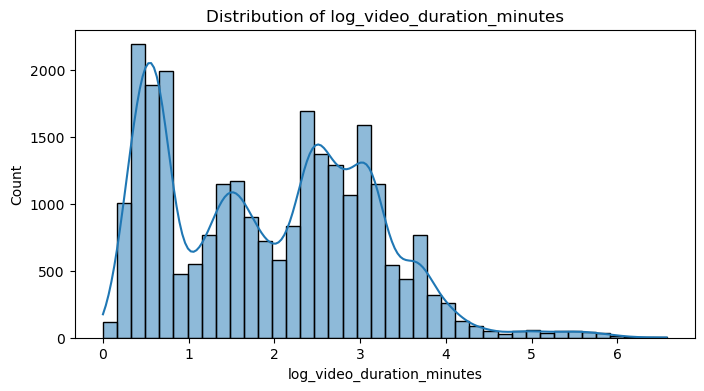

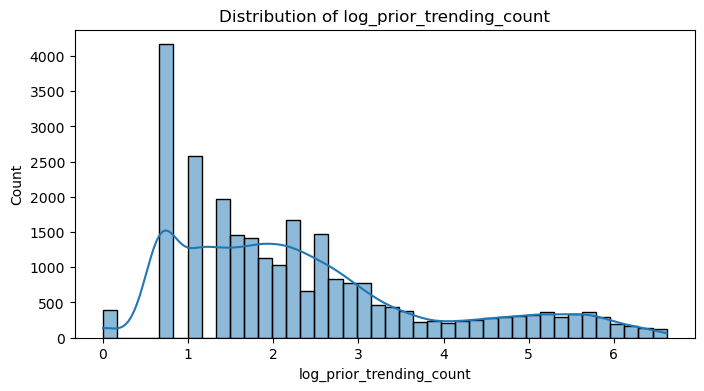

In [71]:
#Log transformed features
numerical_cols_pre_log = ['log_video_duration_minutes', 'log_prior_trending_count']

#Plot and check for each feature after applying log transformation
for col in numerical_cols_pre_log:
    plt.figure(figsize=(8, 4))
    sns.histplot(all_videos_2023_final[col], kde=True, bins=40)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [72]:
##Categorical Pre-upload features

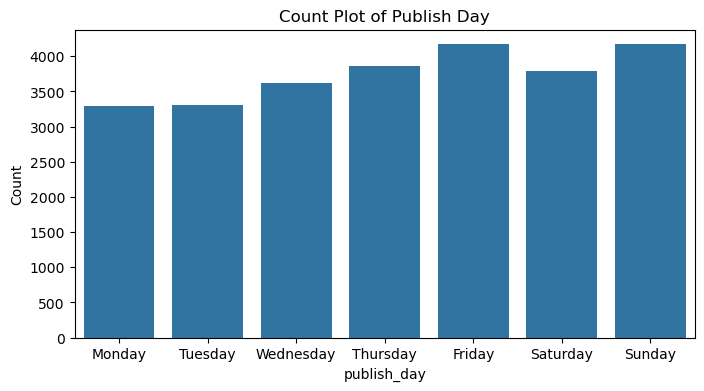

In [73]:
#Publish day 
plt.figure(figsize=(8,4))
sns.countplot(x='publish_day', data=all_videos_2023_final, order=[
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title('Count Plot of Publish Day')
plt.xlabel('publish_day')
plt.ylabel("Count")
plt.show()

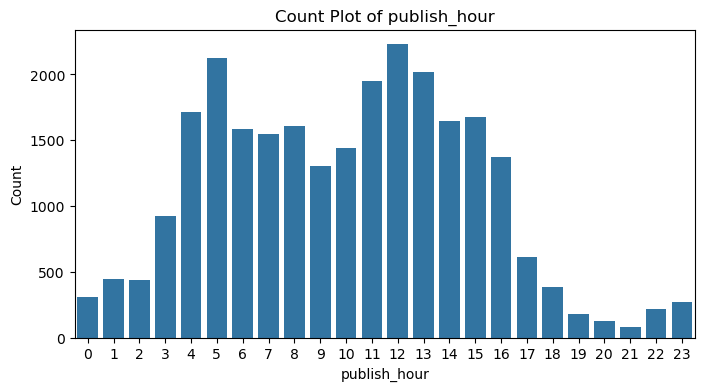

In [74]:
#Publish hour
plt.figure(figsize=(8,4))
sns.countplot(x='publish_hour', data=all_videos_2023_final)
plt.title('Count Plot of publish_hour')
plt.xlabel('publish_hour')
plt.ylabel("Count")
plt.show()

In [75]:
##Textual Pre-upload features (Title, Tags & Description)

In [76]:
##Title

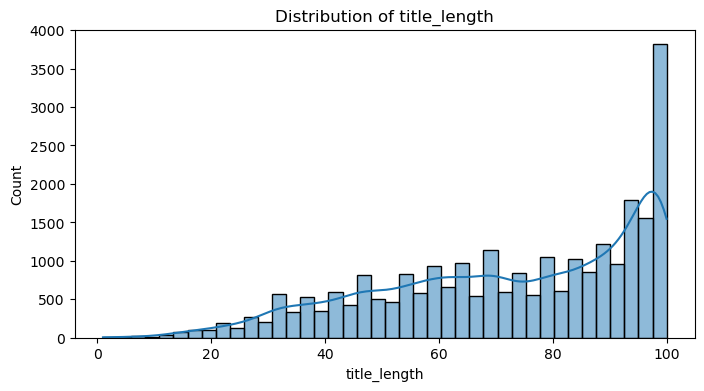

In [77]:
#Plot for Title length
plt.figure(figsize=(8, 4))
sns.histplot(all_videos_2023_final['title_length'], kde=True, bins=40)
plt.title('Distribution of title_length')
plt.xlabel('title_length')
plt.ylabel("Count")
plt.show()

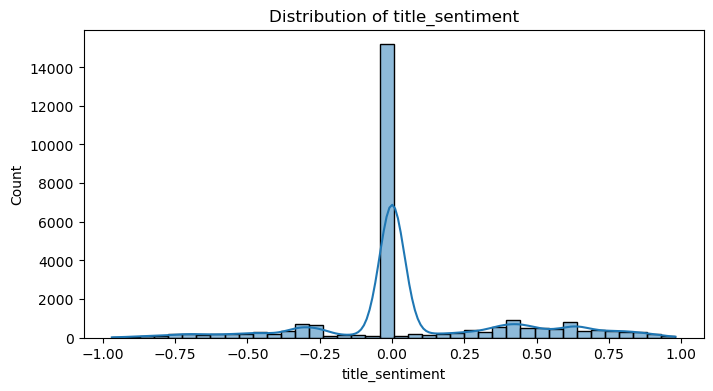

In [78]:
#Plot for Title sentiment
plt.figure(figsize=(8, 4))
sns.histplot(all_videos_2023_final['title_sentiment_compound'], kde=True, bins=40)
plt.title('Distribution of title_sentiment')
plt.xlabel('title_sentiment')
plt.ylabel("Count")
plt.show()

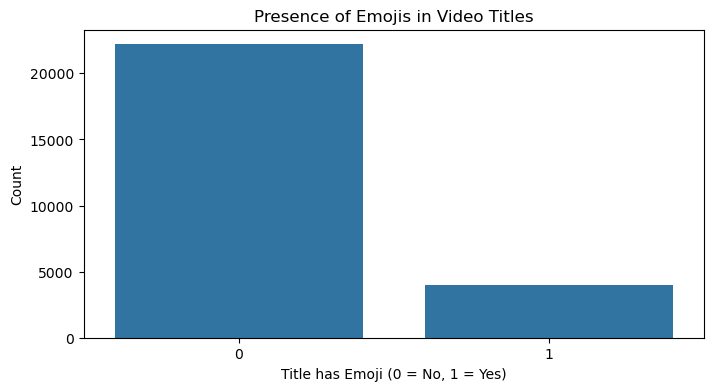

In [79]:
#Plot for Title has emoji
plt.figure(figsize=(8,4))
sns.countplot(x='title_has_emoji', data=all_videos_2023_final)
plt.title("Presence of Emojis in Video Titles")
plt.xlabel("Title has Emoji (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [80]:
##Top 20 words in trending videos title

In [81]:
#Convert dataframe into dict: {word: score}
word_freq = dict(zip(top_words_trend['word'], top_words_trend['trending_ratio']))

#Create word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white',
                      colormap='viridis', 
                      font_path="/System/Library/Fonts/Supplemental/Arial Unicode.ttf").generate_from_frequencies(word_freq)


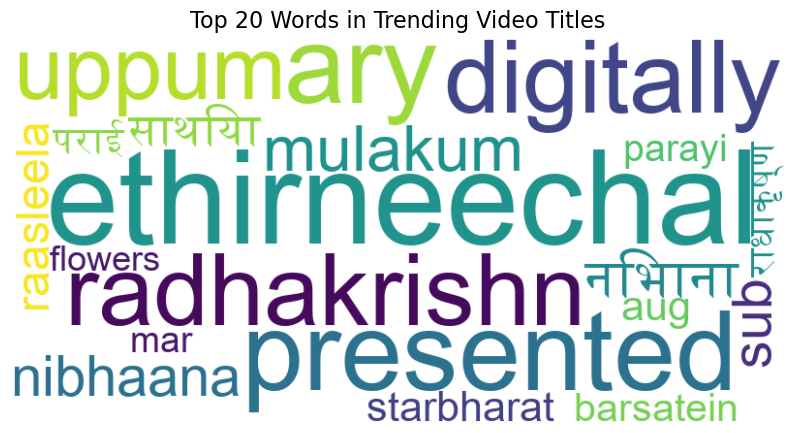

In [82]:
#Plot for trending words
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Top 20 Words in Trending Video Titles", fontsize=16)
plt.show()

In [83]:
##Tags

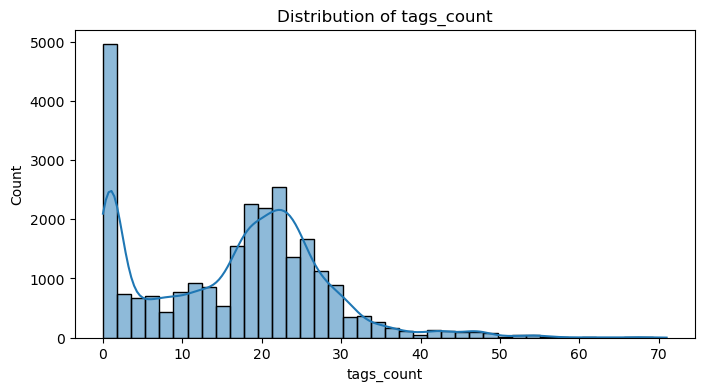

In [84]:
#Plot for Number of tags
plt.figure(figsize=(8, 4))
sns.histplot(all_videos_2023_final['tags_count'], kde=True, bins=40)
plt.title('Distribution of tags_count')
plt.xlabel('tags_count')
plt.ylabel("Count")
plt.show()

In [85]:
##Top 20 tags in trending videos title

In [86]:
#Convert dataframe into dict: {word: score}
tag_freq = dict(zip(top_trending_tags['Tag'], top_trending_tags['Trending_Ratio']))

#Create word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white',
                      colormap='viridis', 
                      font_path="/System/Library/Fonts/Supplemental/Arial Unicode.ttf").generate_from_frequencies(tag_freq)

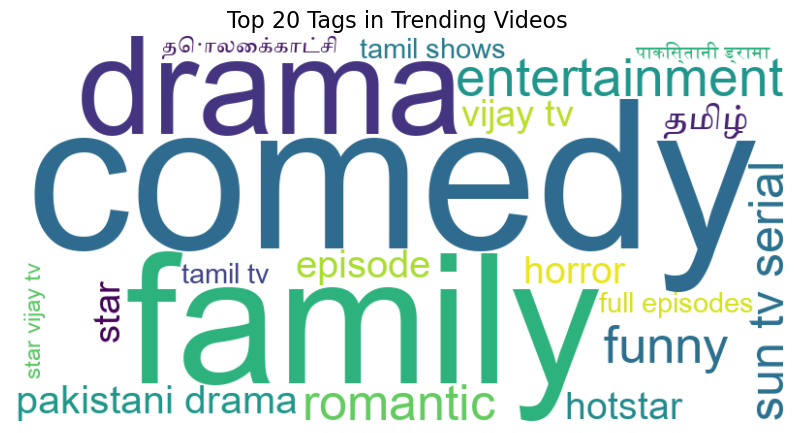

In [87]:
#Plot for trending tags
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Top 20 Tags in Trending Videos", fontsize=16)
plt.show()

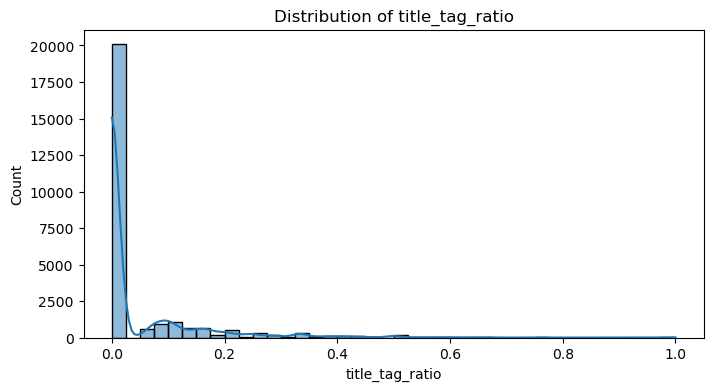

In [88]:
#Plot for Title–Tag Relevance Ratio
plt.figure(figsize=(8, 4))
sns.histplot(all_videos_2023_final['title_tag_ratio'], kde=True, bins=40)
plt.title('Distribution of title_tag_ratio')
plt.xlabel('title_tag_ratio')
plt.ylabel("Count")
plt.show()

In [89]:
##Description

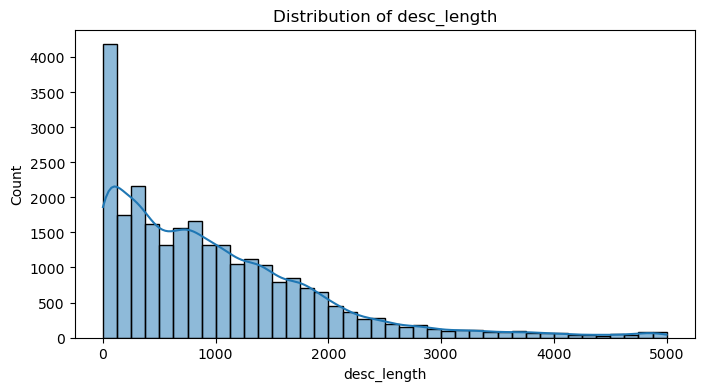

In [90]:
#Plot of actual description length
plt.figure(figsize=(8, 4))
sns.histplot(all_videos_2023_final['desc_length'], kde=True, bins=40)
plt.title('Distribution of desc_length')
plt.xlabel('desc_length')
plt.ylabel("Count")
plt.show()

In [91]:
#Apply log transformation as the plot is right skewed
all_videos_2023_final['log_description_length'] = np.log1p(all_videos_2023_final['desc_length'])

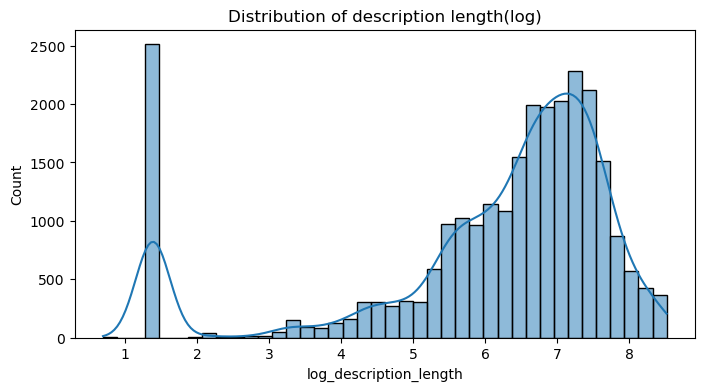

In [92]:
#Plot description length after log transformation
plt.figure(figsize=(8, 4))
sns.histplot(all_videos_2023_final['log_description_length'], kde=True, bins=40)
plt.title('Distribution of description length(log)')
plt.xlabel('log_description_length')
plt.ylabel("Count")
plt.show()

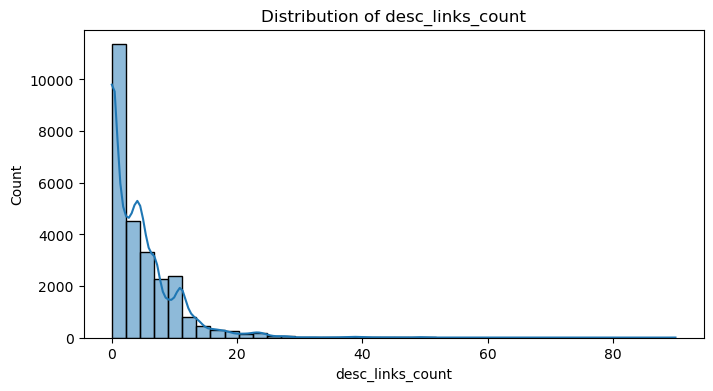

In [93]:
#Plot of links count in description
plt.figure(figsize=(8, 4))
sns.histplot(all_videos_2023_final['desc_links_count'], kde=True, bins=40)
plt.title('Distribution of desc_links_count')
plt.xlabel('desc_links_count')
plt.ylabel("Count")
plt.show()

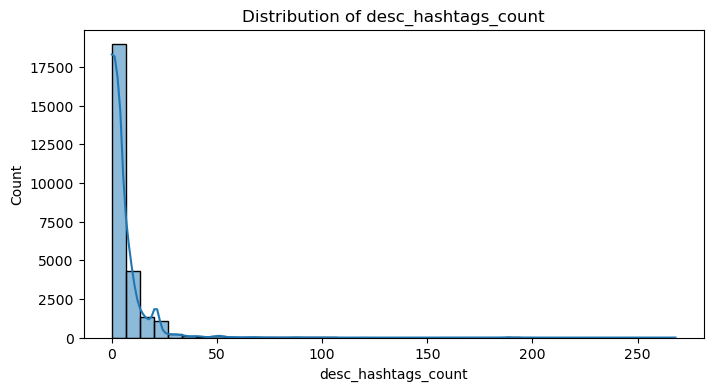

In [94]:
#Plot of hashtags count in description
plt.figure(figsize=(8, 4))
sns.histplot(all_videos_2023_final['desc_hashtags_count'], kde=True, bins=40)
plt.title('Distribution of desc_hashtags_count')
plt.xlabel('desc_hashtags_count')
plt.ylabel("Count")
plt.show()

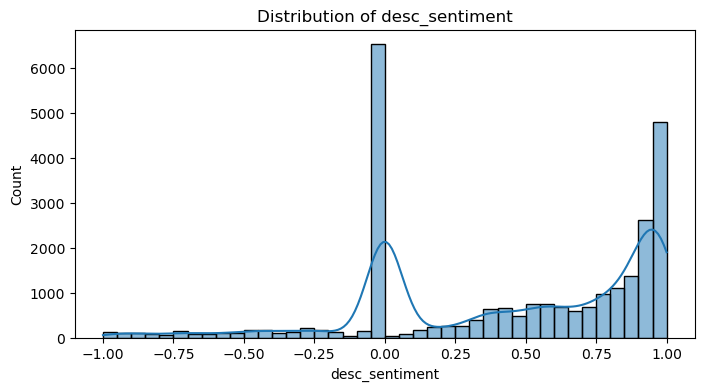

In [95]:
#Plot of description sentiment
plt.figure(figsize=(8, 4))
sns.histplot(all_videos_2023_final['desc_sentiment'], kde=True, bins=40)
plt.title('Distribution of desc_sentiment')
plt.xlabel('desc_sentiment')
plt.ylabel("Count")
plt.show()

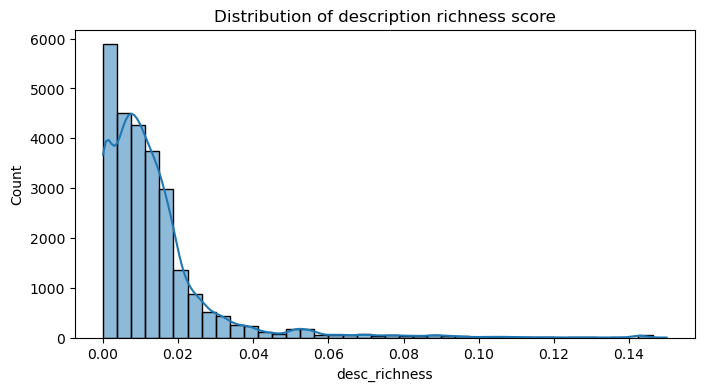

In [96]:
#Plot of description richness score
plt.figure(figsize=(8, 4))
sns.histplot(all_videos_2023_final['desc_richness'], kde=True, bins=40)
plt.title('Distribution of description richness score')
plt.xlabel('desc_richness')
plt.ylabel("Count")
plt.show()

In [97]:
##XXXCombined plots

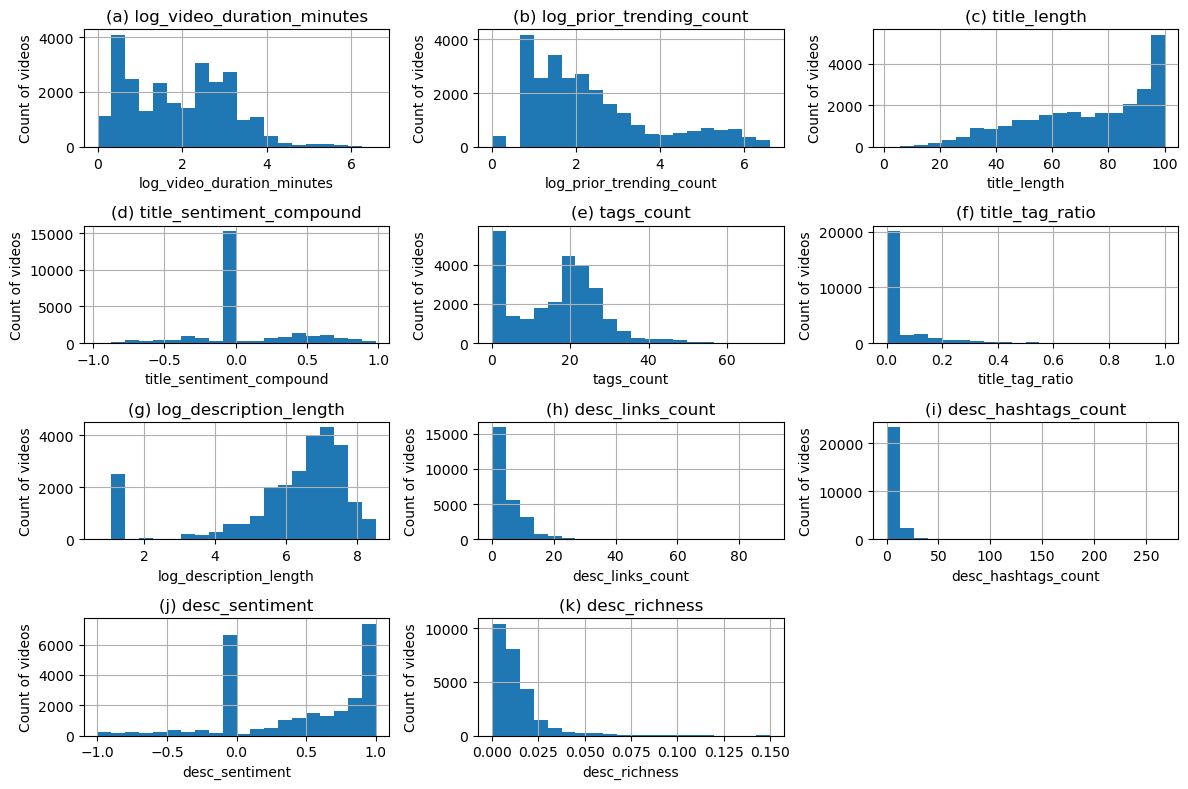

In [98]:
#Numerical features
features_num1 = ['log_video_duration_minutes', 'log_prior_trending_count', 'title_length', 
             'title_sentiment_compound', 'tags_count', 'title_tag_ratio', 'log_description_length', 'desc_links_count', 
             'desc_hashtags_count', 'desc_sentiment', 'desc_richness']

#Histograms for all numeric features at once
axes = all_videos_2023_final[features_num1].hist(bins=20, figsize=(12,8))

#Flatten axes
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
else:
    axes = np.array([axes])

#Add numbering, only for existing axes
for i, (ax, feature) in enumerate(zip(axes, features_num1)):
    ax.set_title(f"({chr(97+i)}) {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count of videos")


plt.tight_layout()
plt.show()

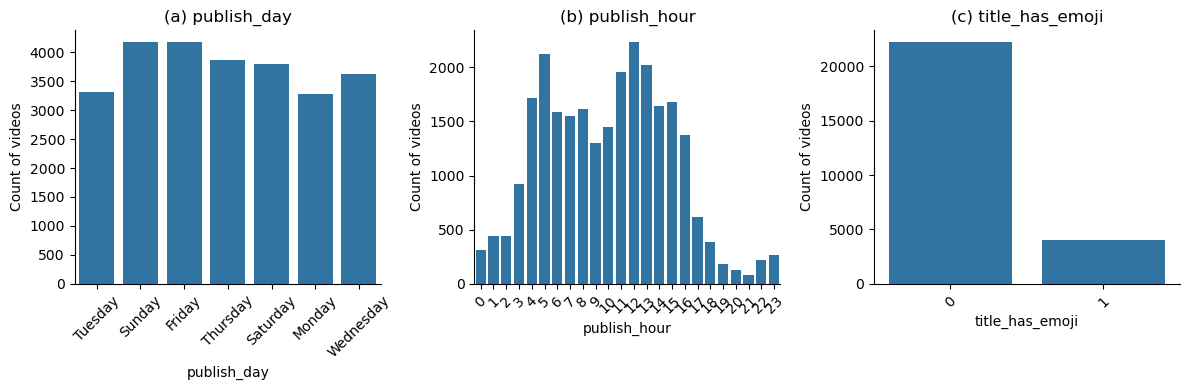

In [99]:
#Count plots for all categorical features at once
#Melt dataframe to long format
cat_df = all_videos_2023_final[features_categ].melt(var_name='Feature', value_name='Category')

g = sns.FacetGrid(cat_df, col="Feature", col_wrap=3, sharex=False, sharey=False, height=4)
g.map_dataframe(sns.countplot, x="Category")

# Add numbering to titles and set x-axis label as feature name
for i, ax in enumerate(g.axes.flat):
    feature_name = ax.get_title().split('=')[1].strip()  # get feature name from FacetGrid title
    ax.set_title(f"({chr(97+i)}) {feature_name}")
    ax.set_xlabel(feature_name)
    ax.set_ylabel("Count of videos")

# Rotate x labels for readability
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Bivariate Analysis

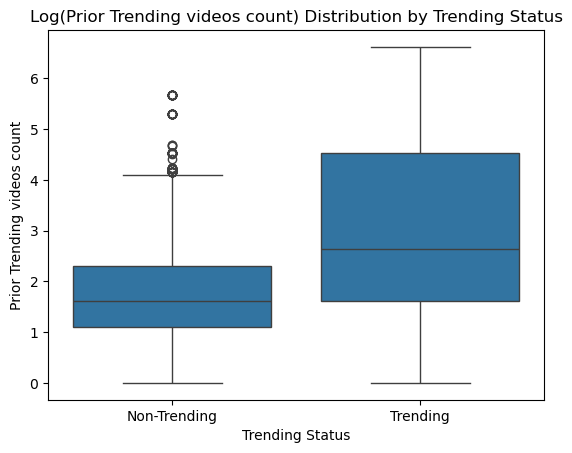

In [101]:
#Rolling count of trending videos per video per channel
sns.boxplot(x='trending_status', y='log_prior_trending_count', data=all_videos_2023_final)
plt.title("Log(Prior Trending videos count) Distribution by Trending Status")
plt.ylabel('Prior Trending videos count')
plt.xlabel('Trending Status')
plt.show()

In [102]:
#Statistical Test
#Mann-Whitney U Test
#Separate the two groups
trending1 = all_videos_2023_final[all_videos_2023_final['trending_status'] == 'Trending']['prior_trending_count']
non_trending1 = all_videos_2023_final[all_videos_2023_final['trending_status'] == 'Non-Trending']['prior_trending_count']

#Run Test
u_stat, p_val = mannwhitneyu(trending1, non_trending1, alternative='two-sided')

print(f"U-statistic: {u_stat:.2f}, P-value: {p_val:.4f}")

U-statistic: 123914147.00, P-value: 0.0000


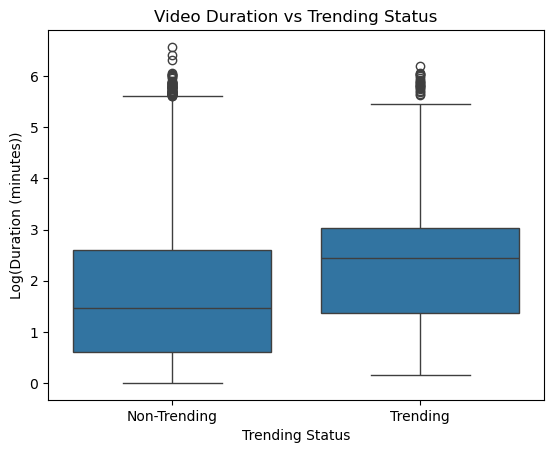

In [103]:
#Video length
#Create another dataframe with no blanks in the column
df = all_videos_2023_final.dropna(subset=['log_video_duration_minutes'])

sns.boxplot(data=df, x='trending_status', y='log_video_duration_minutes')
plt.title('Video Duration vs Trending Status')
plt.ylabel('Log(Duration (minutes))')
plt.xlabel('Trending Status')
plt.show()

In [104]:
#Statistical Test
#Mann-Whitney U Test
#Separate the two groups
trending2 = df[df['trending_status'] == 'Trending']['log_video_duration_minutes']
non_trending2 = df[df['trending_status'] == 'Non-Trending']['log_video_duration_minutes']

#Run Test
u_stat, p_val = mannwhitneyu(trending2, non_trending2, alternative='two-sided')

print(f"U-statistic: {u_stat:.2f}, P-value: {p_val:.4f}")

U-statistic: 103339272.50, P-value: 0.0000


In [105]:
#Publishing time analysis

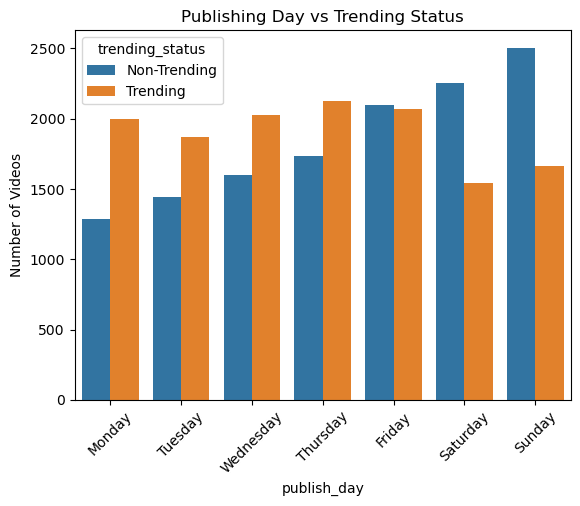

In [106]:
#Publish Day
sns.countplot(data=all_videos_2023_final, x='publish_day', hue='trending_status', order=[
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title("Publishing Day vs Trending Status")
plt.xlabel("publish_day")
plt.ylabel("Number of Videos")
plt.xticks(rotation=45)
plt.show()

In [107]:
#Statistical Test
#Contingency table
ct1 = pd.crosstab(all_videos_2023_final['publish_day'], all_videos_2023_final['trending_status'])

#Chi-Square Test
chi2, p, dof, expected = chi2_contingency(ct1)
print(f"Chi-squared: {chi2:.2f}, P-value: {p:.4f}")

Chi-squared: 596.28, P-value: 0.0000


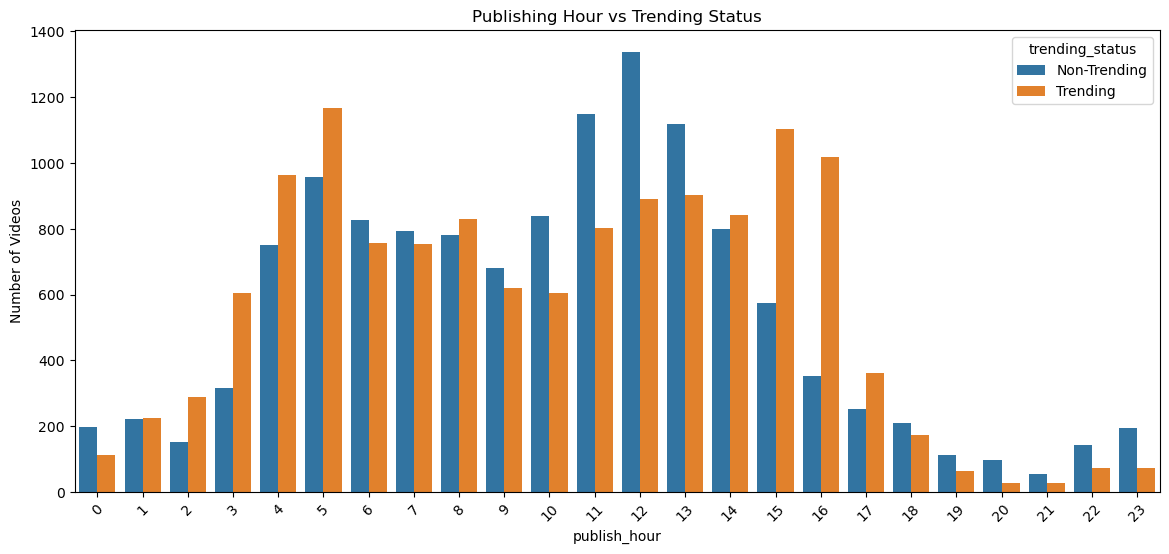

In [108]:
#Publish Hour
plt.figure(figsize=(14, 6))
sns.countplot(data=all_videos_2023_final, x='publish_hour', hue='trending_status')
plt.title("Publishing Hour vs Trending Status")
plt.xlabel("publish_hour")
plt.ylabel("Number of Videos")
plt.xticks(rotation=45)
plt.show()

In [109]:
#Statistical Test
#Contingency table
ct2 = pd.crosstab(all_videos_2023_final['publish_hour'], all_videos_2023_final['trending_status'])

#Chi-Square Test
chi2, p, dof, expected = chi2_contingency(ct2)
print(f"Chi-squared: {chi2:.2f}, P-value: {p:.4f}")

Chi-squared: 1070.67, P-value: 0.0000


In [110]:
#Title

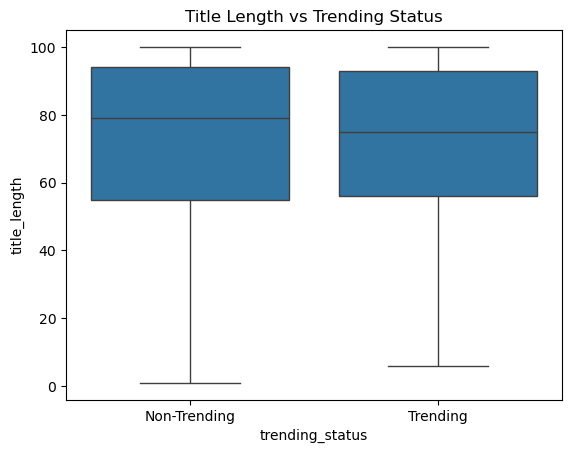

In [111]:
#Title Length
sns.boxplot(data=all_videos_2023_final, x='trending_status', y='title_length')
plt.title('Title Length vs Trending Status')
plt.show()

In [112]:
#Statistical Test
#Mann-Whitney U Test
#Separate the two groups
trending_lengths = all_videos_2023_final[all_videos_2023_final['trending_status'] == 'Trending']['title_length']
non_trending_lengths = all_videos_2023_final[all_videos_2023_final['trending_status'] == 'Non-Trending']['title_length']

#Run test
u_stat, p_val = mannwhitneyu(trending_lengths, non_trending_lengths, alternative='two-sided')

print(f"U-statistic: {u_stat:.2f}, P-value: {p_val:.4f}")

U-statistic: 84119790.00, P-value: 0.0048


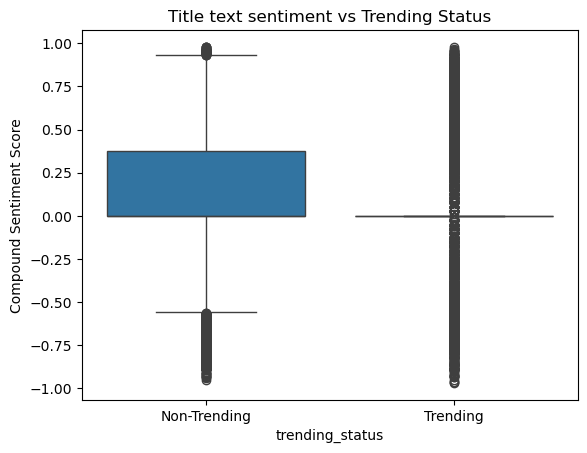

In [113]:
#Title Text sentiment
sns.boxplot(data=all_videos_2023_final, x='trending_status', y='title_sentiment_compound')
plt.title('Title text sentiment vs Trending Status')
plt.xlabel("trending_status")
plt.ylabel("Compound Sentiment Score")
plt.show()

In [114]:
#Statistical Test
#Mann-Whitney U Test
#Separate the two groups
trending_sent = all_videos_2023_final[all_videos_2023_final['trending_status'] == 'Trending']['title_sentiment_compound']
non_trending_sent = all_videos_2023_final[all_videos_2023_final['trending_status'] == 'Non-Trending']['title_sentiment_compound']

#Run test
u_stat, p_val = mannwhitneyu(trending_sent, non_trending_sent, alternative='two-sided')

print(f"U-statistic: {u_stat:.2f}, P-value: {p_val:.4f}")

U-statistic: 75235642.00, P-value: 0.0000


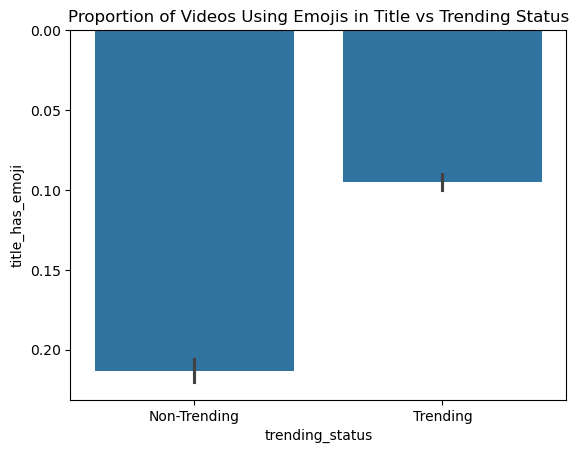

In [115]:
#Title has emoji
sns.barplot(data=all_videos_2023_final, x='trending_status', y='title_has_emoji')
plt.title("Proportion of Videos Using Emojis in Title vs Trending Status")
plt.ylabel("title_has_emoji")
plt.show()

In [116]:
#Statistical Test
#Contingency table
ct3 = pd.crosstab(all_videos_2023_final['title_has_emoji'], all_videos_2023_final['trending_status'])

#Chi-Square Test
chi2, p, dof, expected = chi2_contingency(ct3)
print(f"Chi-squared: {chi2:.2f}, P-value: {p:.4f}")

Chi-squared: 701.85, P-value: 0.0000


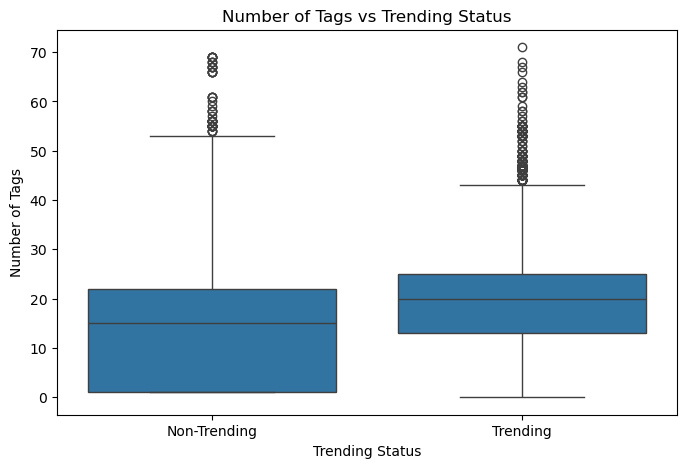

In [117]:
#Tags
#Number of tags
plt.figure(figsize=(8,5))
sns.boxplot(x='trending_status', y='tags_count', data=all_videos_2023_final)
plt.title('Number of Tags vs Trending Status')
plt.xlabel('Trending Status')
plt.ylabel('Number of Tags')
plt.show()

In [118]:
#Statistical Test
#Mann-Whitney U Test
#Separate the two groups
trending_tags = all_videos_2023_final[all_videos_2023_final['trending_status'] == 'Trending']['tags_count']
non_trending_tags = all_videos_2023_final[all_videos_2023_final['trending_status'] == 'Non-Trending']['tags_count']

#Run test
u_stat, p_val = mannwhitneyu(trending_tags, non_trending_tags, alternative='two-sided')

print(f"U-statistic: {u_stat:.2f}, P-value: {p_val:.4f}")

U-statistic: 108649570.50, P-value: 0.0000


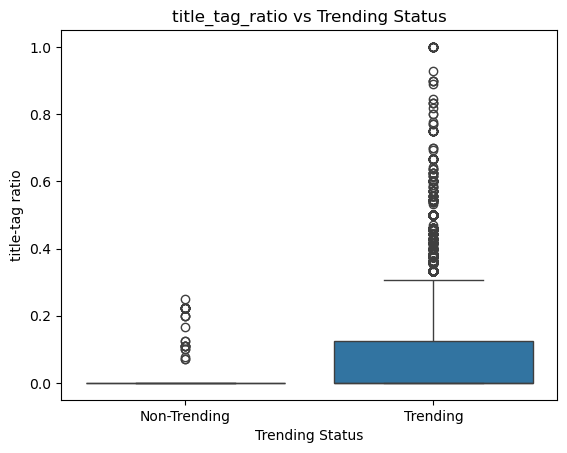

In [119]:
#Title-Tag Relevance Ratio
sns.boxplot(data=all_videos_2023_final, x='trending_status', y='title_tag_ratio')
plt.title("title_tag_ratio vs Trending Status")
plt.ylabel("title-tag ratio")
plt.xlabel("Trending Status")
plt.show()

In [120]:
#Statistical Test
#Mann-Whitney U Test
#Separate the two groups
trending_ratio = all_videos_2023_final[all_videos_2023_final['trending_status'] == 'Trending']['title_tag_ratio']
non_trending_ratio = all_videos_2023_final[all_videos_2023_final['trending_status'] == 'Non-Trending']['title_tag_ratio']

#Run test
u_stat, p_val = mannwhitneyu(trending_ratio, non_trending_ratio, alternative='two-sided')

print(f"U-statistic: {u_stat:.2f}, P-value: {p_val:.4f}")

U-statistic: 125023813.50, P-value: 0.0000


In [121]:
#Description

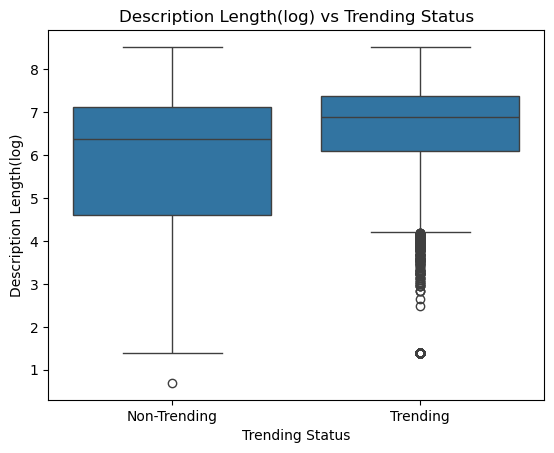

In [122]:
#Description length
sns.boxplot(data=all_videos_2023_final, x='trending_status', y='log_description_length')
plt.title("Description Length(log) vs Trending Status")
plt.ylabel("Description Length(log)")
plt.xlabel("Trending Status")
plt.show()

In [123]:
#Statistical Test
#Mann-Whitney U Test
#Separate the two groups
trending_desc_len = all_videos_2023_final[all_videos_2023_final['trending_status'] == 'Trending']['log_description_length']
non_trending_desc_len = all_videos_2023_final[all_videos_2023_final['trending_status'] == 'Non-Trending']['log_description_length']

#Run test
u_stat, p_val = mannwhitneyu(trending_desc_len, non_trending_desc_len, alternative='two-sided')

print(f"U-statistic: {u_stat:.2f}, P-value: {p_val:.4f}")

U-statistic: 108960478.00, P-value: 0.0000


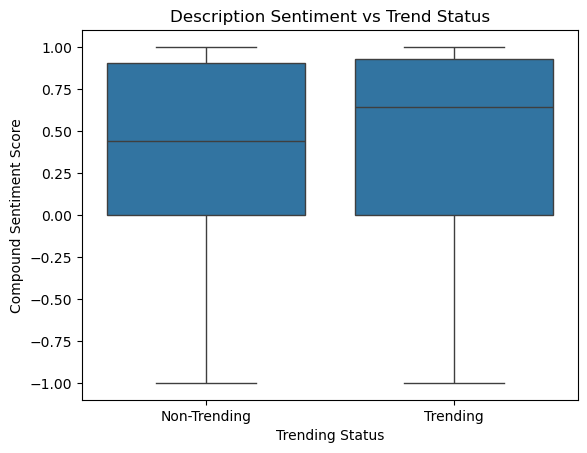

In [124]:
#Description Sentiment
sns.boxplot(data=all_videos_2023_final, x='trending_status', y='desc_sentiment')
plt.title("Description Sentiment vs Trend Status")
plt.ylabel("Compound Sentiment Score")
plt.xlabel("Trending Status")
plt.show()

In [125]:
#Statistical Test
#Mann-Whitney U Test
#Separate the two groups
trending_sent_desc = all_videos_2023_final[all_videos_2023_final['trending_status'] == 'Trending']['desc_sentiment']
non_trending_sent_desc = all_videos_2023_final[all_videos_2023_final['trending_status'] == 'Non-Trending']['desc_sentiment']

#Run test
u_stat, p_val = mannwhitneyu(trending_sent_desc, non_trending_sent_desc, alternative='two-sided')

print(f"U-statistic: {u_stat:.2f}, P-value: {p_val:.4f}")

U-statistic: 94546479.50, P-value: 0.0000


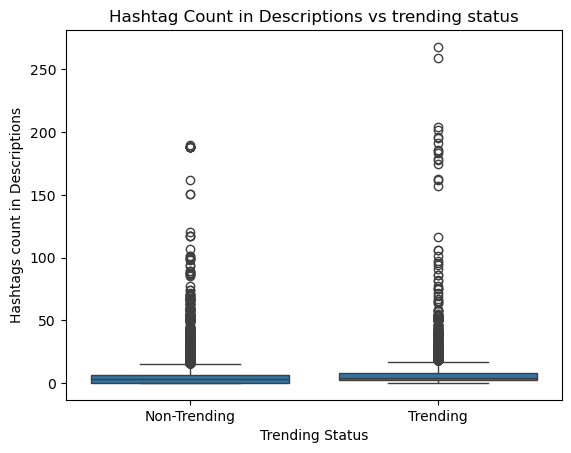

In [126]:
#Number of hashtags in description
sns.boxplot(data=all_videos_2023_final, x='trending_status', y='desc_hashtags_count')
plt.title("Hashtag Count in Descriptions vs trending status")
plt.ylabel("Hashtags count in Descriptions")
plt.xlabel("Trending Status")
plt.show()

In [127]:
#Statistical Test
#Mann-Whitney U Test
#Separate the two groups
trending_hash_tag = all_videos_2023_final[all_videos_2023_final['trending_status'] == 'Trending']['desc_hashtags_count']
non_trending_hash_tag = all_videos_2023_final[all_videos_2023_final['trending_status'] == 'Non-Trending']['desc_hashtags_count']

#Run test
u_stat, p_val = mannwhitneyu(trending_hash_tag, non_trending_hash_tag, alternative='two-sided')

print(f"U-statistic: {u_stat:.2f}, P-value: {p_val:.4f}")

U-statistic: 105826251.50, P-value: 0.0000


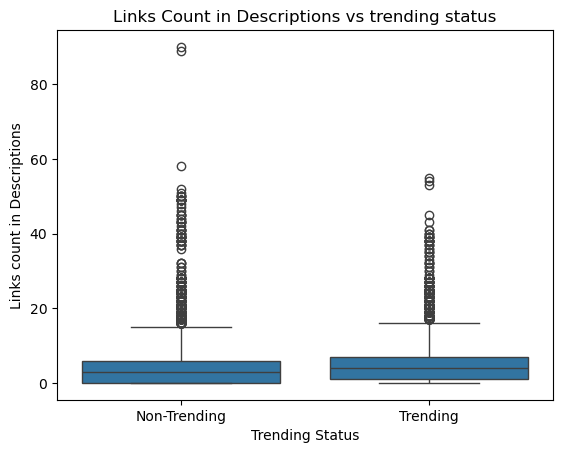

In [128]:
#Number of links in description
sns.boxplot(data=all_videos_2023_final, x='trending_status', y='desc_links_count')
plt.title("Links Count in Descriptions vs trending status")
plt.ylabel("Links count in Descriptions")
plt.xlabel("Trending Status")
plt.show()

In [129]:
#Statistical Test
#Mann-Whitney U Test
#Separate the two groups
trending_links = all_videos_2023_final[all_videos_2023_final['trending_status'] == 'Trending']['desc_links_count']
non_trending_links = all_videos_2023_final[all_videos_2023_final['trending_status'] == 'Non-Trending']['desc_links_count']

#Run test
u_stat, p_val = mannwhitneyu(trending_links, non_trending_links, alternative='two-sided')

print(f"U-statistic: {u_stat:.2f}, P-value: {p_val:.4f}")

U-statistic: 100543089.50, P-value: 0.0000


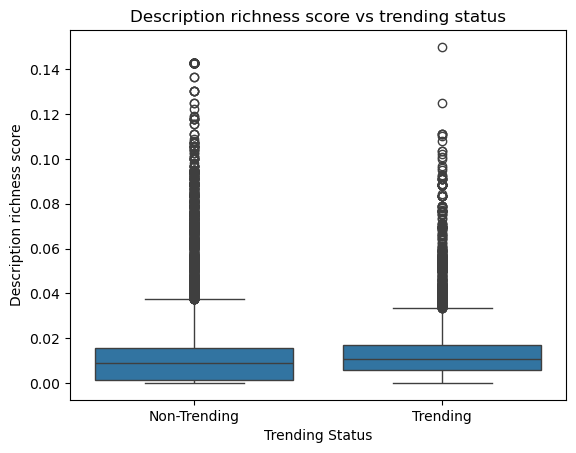

In [130]:
#Description richness score
sns.boxplot(data=all_videos_2023_final, x='trending_status', y='desc_richness')
plt.title("Description richness score vs trending status")
plt.ylabel("Description richness score")
plt.xlabel("Trending Status")
plt.show()

In [131]:
#Statistical Test
#Mann-Whitney U Test
#Separate the two groups
trending_desc_rich = all_videos_2023_final[all_videos_2023_final['trending_status'] == 'Trending']['desc_richness']
non_trending_desc_rich = all_videos_2023_final[all_videos_2023_final['trending_status'] == 'Non-Trending']['desc_richness']

#Run test
u_stat, p_val = mannwhitneyu(trending_desc_rich, non_trending_desc_rich, alternative='two-sided')

print(f"U-statistic: {u_stat:.2f}, P-value: {p_val:.4f}")

U-statistic: 97633673.00, P-value: 0.0000


In [132]:
#Combined plots

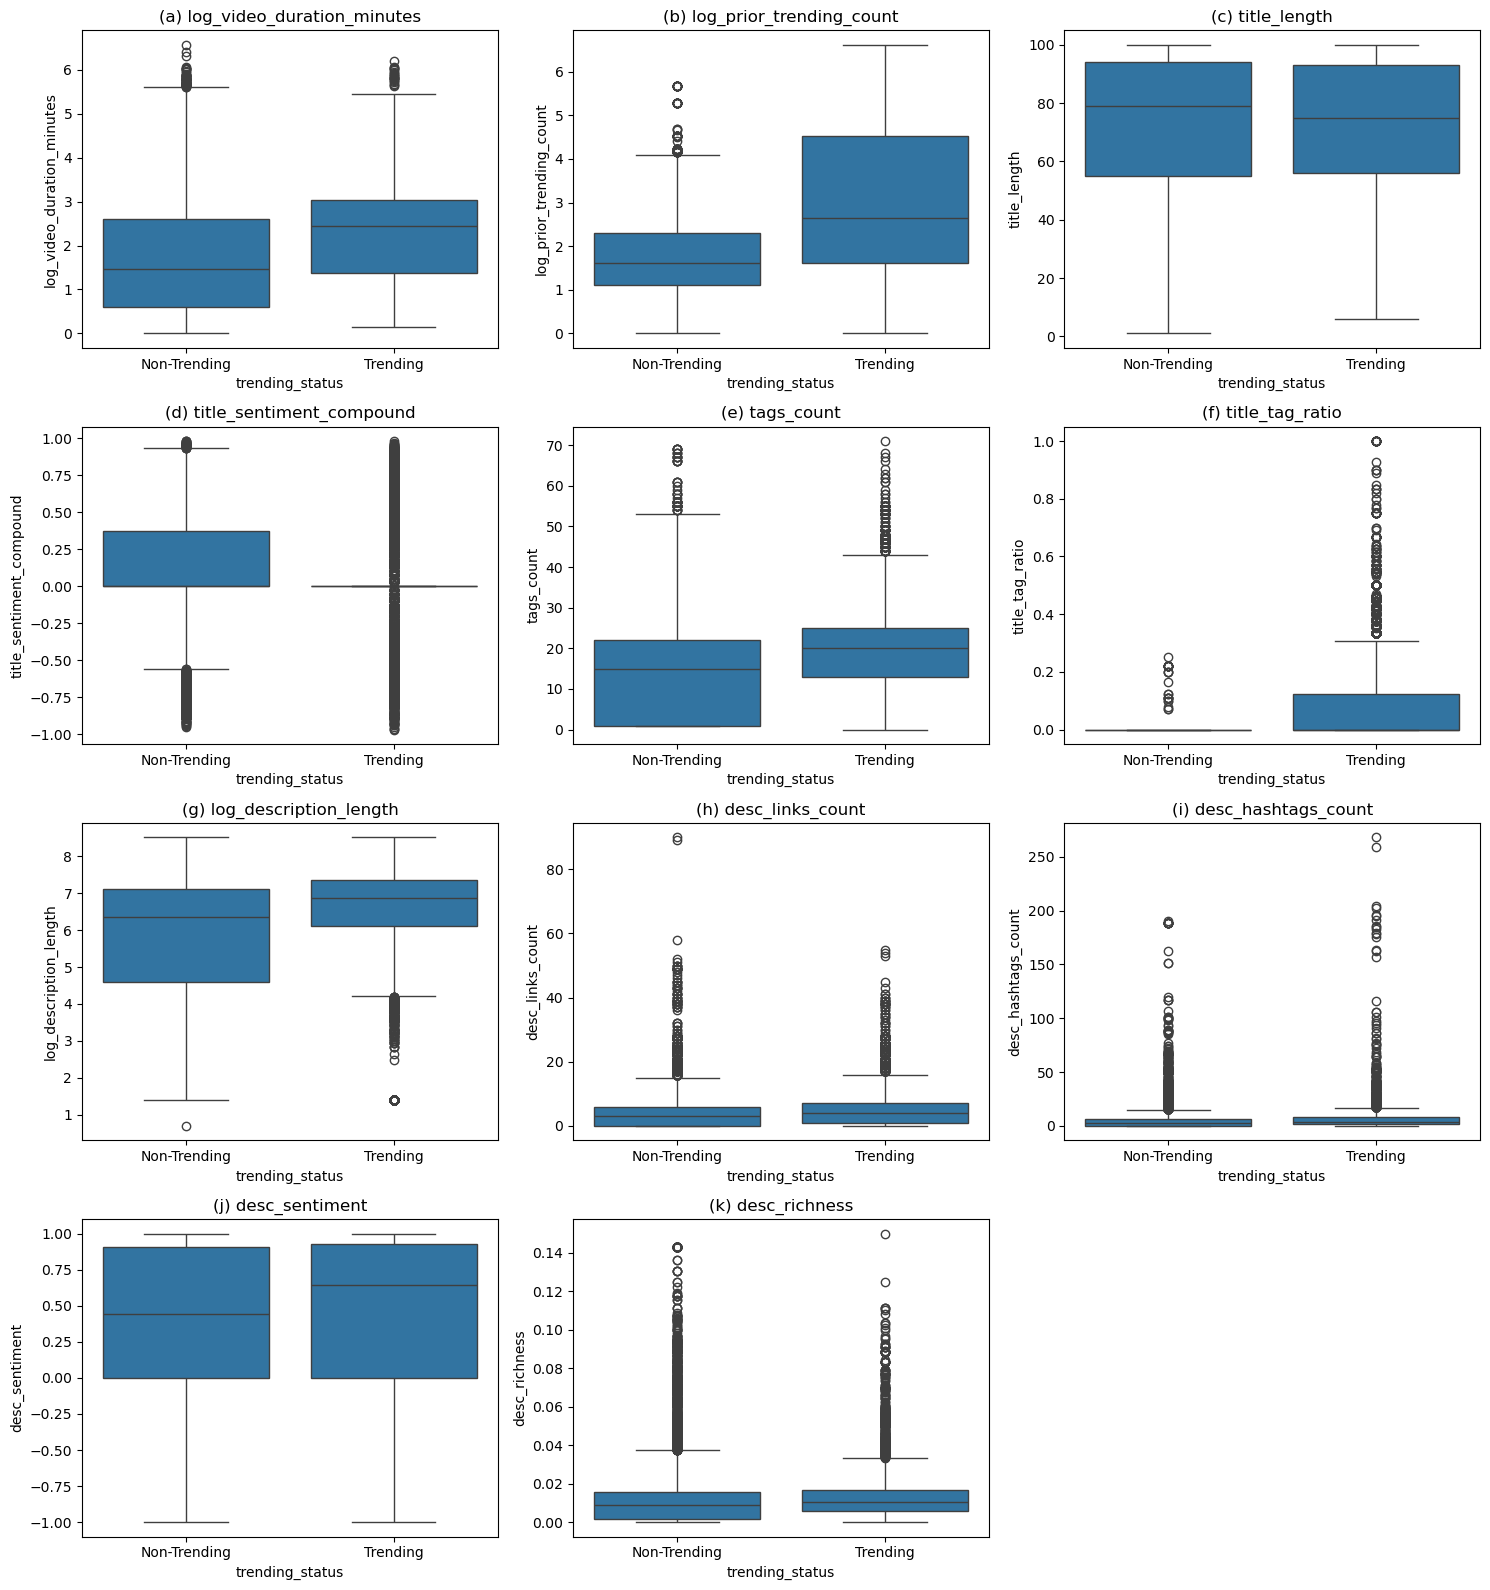

In [133]:
#Box plots for numerical features
n_cols = 3
n_rows = (len(features_num1) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
#Ensure axes is always a flat array
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
else:
    axes = [axes]

for i, feature in enumerate(features_num1):
    sns.boxplot(x="trending_status", y=feature, data=all_videos_2023_final, ax=axes[i])
    axes[i].set_title(f"({chr(97+i)}) {feature}")

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

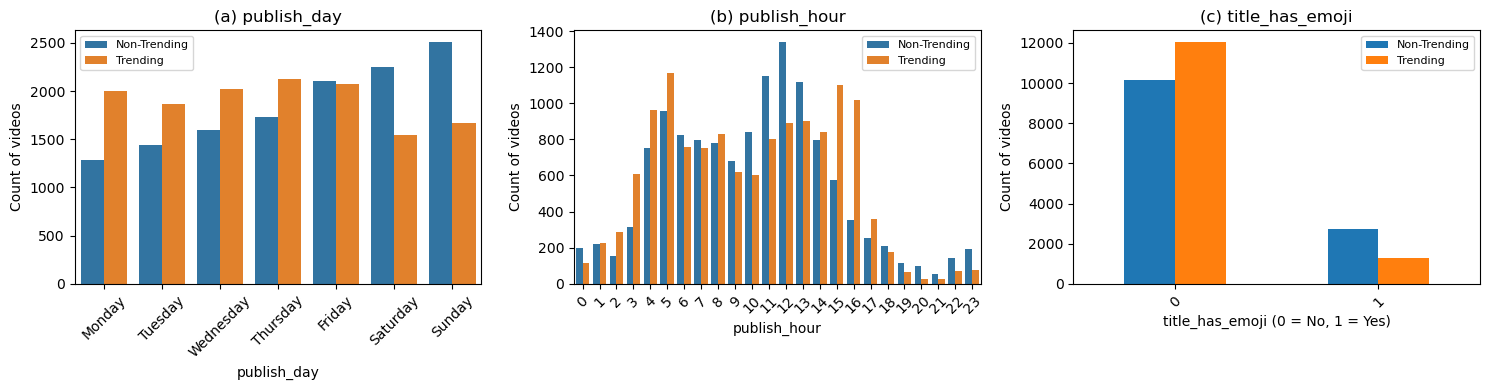

In [134]:
##Count plots and bar plots for categorical features
fig, axes = plt.subplots(1, len(features_categ), figsize=(5*len(features_categ), 4))

for i, feature in enumerate(features_categ):
    if feature == "title_has_emoji":
        #Grouped bar plot for emoji presence
        prop = pd.crosstab(all_videos_2023_final[feature], all_videos_2023_final['trending_status'])
        prop.plot(kind='bar', ax=axes[i])
        axes[i].set_ylabel("Count of videos")
        axes[i].set_title(f"({chr(97+i)}) {feature}")
        axes[i].legend(labels=['Non-Trending', 'Trending'])
        #Adjust legend
        axes[i].legend(labels=['Non-Trending', 'Trending'], fontsize=8, title_fontsize=9)
        #Set x label
        axes[i].set_xlabel("title_has_emoji (0 = No, 1 = Yes)")
    elif feature == "publish_day":
        #Countplots for publish day
        sns.countplot(x=feature, hue="trending_status", data=all_videos_2023_final, ax=axes[i], order=[
            'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
        axes[i].set_title(f"({chr(97+i)}) {feature}")
        axes[i].set_ylabel("Count of videos")
        axes[i].legend(labels=['Non-Trending', 'Trending'])
        #Adjust legend
        axes[i].legend(labels=['Non-Trending', 'Trending'], fontsize=8, title_fontsize=9)
        
    else:
        #Countplots for publish hour
        sns.countplot(x=feature, hue="trending_status", data=all_videos_2023_final, ax=axes[i])
        axes[i].set_title(f"({chr(97+i)}) {feature}")
        axes[i].set_ylabel("Count of videos")
        axes[i].legend(labels=['Non-Trending', 'Trending'])
        #Adjust legend
        axes[i].legend(labels=['Non-Trending', 'Trending'], fontsize=8, title_fontsize=9)
    
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [135]:
##combined statistical tests
#Split data into trending vs non-trending
trending_all = all_videos_2023_final[all_videos_2023_final["trending_status"] == 'Trending']
non_trending_all = all_videos_2023_final[all_videos_2023_final["trending_status"] == 'Non-Trending']

results = []

#Numerical Features (Mann-Whitney U)
for col in features_num1:
    group1 = trending_all[col].dropna()
    group0 = non_trending_all[col].dropna()
    stat, p = stats.mannwhitneyu(group1, group0, alternative="two-sided")
    results.append([col, "Mann-Whitney U", stat, p])


#Categorical Features (Chi-square)
for col in features_categ:
    contingency = pd.crosstab(all_videos_2023_final[col], all_videos_2023_final["trending_status"])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    results.append([col, "Chi-square", chi2, p])

df_stats = pd.DataFrame(results, columns=["Feature", "Test Used", "Test Statistic", "p-value"])

#Round test statistic to 2 decimals
df_stats["Test Statistic"] = df_stats["Test Statistic"].apply(lambda x: round(x, 2) if pd.notnull(x) else "")

#Round p-value to 3 decimals
def format_pval(p):
    if pd.isnull(p):
        return ""
    elif p < 0.001:
        return "<0.001"
    else:
        return round(p, 3)

df_stats["p-value"] = df_stats["p-value"].apply(format_pval)

def significance(p):
    if p == "" or p is None:
        return "No"
    elif p == "<0.001":
        return "Yes"
    else:
        return "Yes" if float(p) < 0.05 else "No"

df_stats["Significant"] = df_stats["p-value"].apply(significance)

print(df_stats)

                       Feature       Test Used  Test Statistic p-value  \
0   log_video_duration_minutes  Mann-Whitney U    1.033393e+08  <0.001   
1     log_prior_trending_count  Mann-Whitney U    1.239141e+08  <0.001   
2                 title_length  Mann-Whitney U    8.411979e+07   0.005   
3     title_sentiment_compound  Mann-Whitney U    7.523564e+07  <0.001   
4                   tags_count  Mann-Whitney U    1.086496e+08  <0.001   
5              title_tag_ratio  Mann-Whitney U    1.250238e+08  <0.001   
6       log_description_length  Mann-Whitney U    1.089605e+08  <0.001   
7             desc_links_count  Mann-Whitney U    1.005431e+08  <0.001   
8          desc_hashtags_count  Mann-Whitney U    1.058263e+08  <0.001   
9               desc_sentiment  Mann-Whitney U    9.454648e+07  <0.001   
10               desc_richness  Mann-Whitney U    9.763367e+07  <0.001   
11                 publish_day      Chi-square    5.962800e+02  <0.001   
12                publish_hour      Ch

In [136]:
df_stats.to_csv(folder_path + "statistical_tests_summary.csv", index=False)

In [137]:
all_videos_2023_final.columns

Index(['video_id', 'title', 'tags', 'description', 'video_duration_seconds',
       'trending_status', 'prior_trending_count', 'publish_day',
       'publish_hour', 'title_length', 'title_sentiment_compound',
       'title_has_emoji', 'title_tokens', 'tag_tokens', 'tags_count',
       'title_tag_ratio', 'desc_length', 'desc_links_count',
       'desc_hashtags_count', 'desc_sentiment', 'desc_richness',
       'video_duration_minutes', 'log_video_duration_minutes',
       'log_prior_trending_count', 'log_description_length'],
      dtype='object')

In [138]:
#Keep only the significant columns
all_videos_2023_final_req_col = all_videos_2023_final[['video_id', 'trending_status', 'video_duration_minutes',
                                                       'log_prior_trending_count', 'publish_day','publish_hour',
                                                       'log_video_duration_minutes', 'title_length', 'title_sentiment_compound', 
                                                       'title_has_emoji', 'tags_count', 'title_tag_ratio', 'log_description_length', 'desc_links_count',
                                                       'desc_hashtags_count', 'desc_sentiment', 'desc_richness']].drop_duplicates()

In [139]:
all_videos_2023_final_req_col.shape

(26209, 17)

In [140]:
all_videos_2023_final_req_col.to_csv(folder_path + 'youtube_trending_videos_statistics.csv', index=False)